# MCVR: do medial or lateral MEC cells discriminate context (rz1 vs rz2) better?

**Why this isn't a MEC-vs-LEC test.** Checking the `brain_region` field across
all 6 MCVR mice's curated units turns up zero lateral entorhinal cortex (ENTl)
cells anywhere in this cohort -- only medial entorhinal (`ENTm1/2/3/5/6`),
`PRE`/`SUB`/`PAR`, and (in a couple of mice whose probe missed the
hippocampal formation) visual cortex or cerebellar labels. LEC exists in this
lab's anatomical-registration vocabulary (it shows up in one clark2025
mouse, M21), it just was never sampled here. So "medial vs. lateral" here
means **mediolateral anatomical position of the recording shank**, not
cell-type identity.

**Restricted to MEC only.** The original version of this analysis used
every curated cell regardless of region, which meant the medial/lateral
split was partly confounded with region identity (`PRE`/`PAR` are almost
entirely medial, `SUB` mostly lateral). To get a cleaner test of the
mediolateral question itself, this version restricts to
`ENTm1/ENTm2/ENTm3/ENTm5/ENTm6` only, dropping `PRE`/`SUB`/`PAR` and any
non-hippocampal-formation cells entirely. **This substantially narrows
scope**: only 16/31 sessions, across just 4 mice (`M25`, `M26`, `M28`,
`M29`), have >=15 medial *and* >=15 lateral curated MEC cells -- `M22`'s
probe recorded essentially no MEC at all (it was in `PRE`/`SUB`/`PAR`),
and `M27`'s was almost entirely outside the hippocampal formation
(cerebellar/vestibular), consistent with both mice being weak/absent
context-decoders in the earlier all-region version.

**How medial/lateral is defined.** These are 4-shank probes; each unit's
`coord_CCFs_x` is essentially constant within a shank (shanks land at ~4
discrete x values ~150-700um apart) and is otherwise flat/uninformative
across `coord_CCFs_y` (depth) and `coord_CCFs_z` (AP, narrow range) --
i.e. `coord_CCFs_x` is the shank-separating, mediolateral CCF axis.
Direction: `brainrender_helper.py`'s own `CCFToStereo` subtracts a
reference offset of `(5400, 440, 5700)` from raw CCF coordinates, where
5700 is the standard CCF midline value for the ML axis -- our units'
`coord_CCFs_x` (1980-2700) sit entirely on one side of that, well below
5700, so **larger x = closer to the midline = more medial**, smaller x =
further from midline = more lateral. Each unit is labelled medial/lateral
by a **per-session median split** on its own `coord_CCFs_x`.

**Methods, in order below:**
1. **Population decoding accuracy**, medial-only vs. lateral-only
   (cell-count-matched) vs. all cells.
2. **Ablation order curves** -- strip lateral-first vs. medial-first,
   tracking the remaining population's decoding accuracy.
3. **Single-cell context selectivity** -- per-unit ROC-AUC, medial vs.
   lateral.
4. **Speed confound control** -- does the *shape* (not just level) of
   the running-speed profile explain any of this, checked both as a
   behaviour-only decoding ceiling and via bin-wise residualization of
   each cell's own local speed-tuning.
5. **Context selectivity beyond speed (XGBoost)** -- per-cell test of
   whether that cell's activity improves context decoding *on top of*
   the speed profile shape, using a non-linear model (XGBoost) that
   doesn't assume the speed relationship is linear the way the OLS
   residualization in (4) does.
6. **Novel (`rz2`) vs. familiar (`rz1`) selectivity** -- does each
   population skew toward preferring the novel or the familiar context,
   not just how *strongly* selective they are.

In [1]:
import sys, os, glob, re, time
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynapple as nap
from spatial_manifolds.data.curation import curate_clusters
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from scipy.stats import wilcoxon, mannwhitneyu, chi2_contingency
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Arial'

SOURCE_PATH = '/Users/harryclark/Downloads/harry_multi_context_vr/dataset/'
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'
CACHE_DIR = os.path.join(FIGPATH, 'mcvr_ml_decoding')
os.makedirs(CACHE_DIR, exist_ok=True)

BS, TL = 2, 230          # cm per bin, track length -- matches the other MCVR notebooks
MIN_SPEED = 3.0          # cm/s, matches the anchoring notebook's `moving` epoch
MIN_ML_CELLS = 15        # minimum medial AND lateral curated cells to include a session
N_SUBSAMPLE = 20         # repeats for cell-count-matched subsampling
CV_FOLDS = 5
MEC_REGIONS = {'ENTm1', 'ENTm2', 'ENTm3', 'ENTm5', 'ENTm6'}   # medial entorhinal only -- see markdown above
EXCLUDE_MICE = {'M22', 'M27'}   # no usable MEC recordings (M22: 16 MEC cells total, M27: 73, across 5 sessions each)

CTX1_COLOR, CTX2_COLOR = '#2ca02c', '#d62728'   # rz1 (familiar) / rz2 (novel), matches other AnchorDynamics2026 notebooks
MEDIAL_COLOR, LATERAL_COLOR = '#1f4e9c', '#e8871e'
ALL_COLOR = '0.3'

SESSION_FILES = sorted(glob.glob(os.path.join(SOURCE_PATH, 'sub-*', '*.nwb')))
print(f'{len(SESSION_FILES)} MCVR ecephys+behaviour sessions found')

31 MCVR ecephys+behaviour sessions found


## Data availability: medial vs. lateral MEC cell counts per session

Loads every session's curated units, restricts to `ENTm1/2/3/5/6` only,
then applies the per-session `coord_CCFs_x` median split -- this both
decides which sessions clear the `MIN_ML_CELLS` bar and doubles as an
anatomical sanity check (which entorhinal layers land medial vs. lateral
within this MEC-only pool).

In [2]:
session_rows = []
session_data = {}   # mouse, day -> dict with units metadata + medial/lateral labels, kept in memory for reuse below

for f in SESSION_FILES:
    m = re.search(r'sub-(M\d+)_ses-D(\d+)MCVR', os.path.basename(f))
    mouse, day = m.group(1), int(m.group(2))
    if mouse in EXCLUDE_MICE:
        session_rows.append(dict(mouse=mouse, day=day, n_units=0, n_medial=0, n_lateral=0, included=False))
        continue
    data = nap.load_file(f)
    units = curate_clusters(data['units'])
    meta = units.metadata.dropna(subset=['coord_CCFs_x'])
    meta = meta[meta['brain_region'].isin(MEC_REGIONS)]   # MEC only -- see title markdown
    n_valid = len(meta)
    if n_valid == 0:
        session_rows.append(dict(mouse=mouse, day=day, n_units=0, n_medial=0, n_lateral=0, included=False))
        continue

    med_split = meta['coord_CCFs_x'].median()
    is_medial = meta['coord_CCFs_x'] >= med_split
    n_medial, n_lateral = int(is_medial.sum()), int((~is_medial).sum())
    included = min(n_medial, n_lateral) >= MIN_ML_CELLS
    session_rows.append(dict(mouse=mouse, day=day, n_units=n_valid, n_medial=n_medial,
                              n_lateral=n_lateral, included=included))
    if included:
        # keep only the valid-coordinate, curated, MEC-only units for the analyses below
        valid_ids = meta.index
        session_data[(mouse, day)] = dict(
            path=f, units=units[valid_ids], meta=meta,
            is_medial=pd.Series(is_medial.values, index=valid_ids))

session_df = pd.DataFrame(session_rows)
included_sessions = [(r.mouse, r.day) for r in session_df[session_df.included].itertuples()]
print(f'{len(included_sessions)}/{len(session_df)} sessions included '
      f'(MEC only, min(medial,lateral) >= {MIN_ML_CELLS}, excluding {sorted(EXCLUDE_MICE)})')
print(f'mice: {sorted(set(m for m, _ in included_sessions))}')
session_df

16/31 sessions included (MEC only, min(medial,lateral) >= 15)


,mouse,day,n_units,n_medial,n_lateral,included
0,M22,42,5,5,0,False
1,M22,43,5,5,0,False
2,M22,44,0,0,0,False
3,M22,45,0,0,0,False
4,M22,46,6,6,0,False
5,M25,26,212,113,99,True
6,M25,27,244,244,0,False
7,M25,28,273,191,82,True
8,M25,29,135,135,0,False
9,M25,30,299,213,86,True


In [3]:
# anatomical sanity check: pooled brain_region composition, medial vs lateral half, across all included sessions
region_rows = []
for (mouse, day), d in session_data.items():
    meta = d['meta']
    for region, is_med in zip(meta['brain_region'], d['is_medial']):
        region_rows.append(dict(region=region, side='medial' if is_med else 'lateral'))
region_df = pd.DataFrame(region_rows)
region_table = pd.crosstab(region_df['region'], region_df['side'])
region_table['pct_medial'] = 100 * region_table['medial'] / (region_table['medial'] + region_table['lateral'])
print(region_table.sort_values('pct_medial', ascending=False))

side    lateral  medial  pct_medial
region                             
ENTm1         0     258  100.000000
ENTm2         7     617   98.878205
ENTm3       484    1019   67.797738
ENTm5       747     354   32.152589


## Per-session trial x cell firing-rate matrix

Reuses the same trick as the anchoring notebook (`nap.compute_1d_tuning_curves`
over a `travel`-based position axis spanning the whole session, one call per
session) rather than reimplementing spike counting -- the resulting
position-binned rate matrix is then averaged **within each trial** to give
one mean firing rate per cell per trial, restricted to `moving` epochs
(speed > `MIN_SPEED`) exactly as elsewhere. This trial x cell rate matrix
is the shared input to all three methods below.

In [4]:
COARSEN = 5                      # 5 fine bins (2cm) -> one 10cm coarse bin
N_COARSE = int(TL / BS) // COARSEN   # 115 // 5 = 23 coarse bins across the trial

def coarsen_profile(profile, factor=COARSEN):
    """(n_trials, n_bins) or (n_trials, n_bins, n_units) -> nanmean over `factor`
    adjacent fine bins, NaN-filled with 0. 115 fine bins divides evenly into 23."""
    if profile.ndim == 2:
        n_trials, n_bins = profile.shape
        r = profile.reshape(n_trials, n_bins // factor, factor)
        axis = 2
    else:
        n_trials, n_bins, n_units = profile.shape
        r = profile.reshape(n_trials, n_bins // factor, factor, n_units)
        axis = 2
    with np.errstate(invalid='ignore'):
        return np.nan_to_num(np.nanmean(r, axis=axis))

def get_trial_rate_matrix(mouse, day, d):
    """Returns trial-level rates plus COARSE POSITION-BINNED profiles.

    rates / residual_rates: (n_trials, n_units) trial-mean firing rate, raw and
      with each cell's bin-wise linear speed-dependence removed.
    rate_profile_coarse: (n_trials, N_COARSE, n_units) -- each cell's firing rate
      profile ACROSS the trial, at 10cm resolution. This is what the
      profile-based analyses use; the trial-mean collapses it away and is blind
      to any spatial restructuring between contexts.
    speed_profile_coarse: (n_trials, N_COARSE) matching speed profile.
    types / blocks: per-trial trial type ('b' beaconed / 'nb' non-beaconed) and
      block index ((trial number - 1) // 20). Blocks are 20 trials, alternating
      rz1/rz2 with rz1 leading; even block indices are rz1, odd are rz2. Some
      sessions begin mid-block, so block 0 can be partial -- count trials per
      block before using a block as a train or test set.
    """
    data = nap.load_file(d['path'])
    trials_df = data['trials'].as_dataframe()
    n_trials = len(trials_df)
    units = d['units']
    n_units = len(units)

    tns = data['trial_number']
    travel = data['travel']
    dt = travel - (float(tns.values[0]) - 1) * TL
    moving = data['S'].threshold(MIN_SPEED, method='above').time_support
    n_bins_per_trial = int(TL / BS)
    nb_bins_total = n_trials * n_bins_per_trial

    tc = nap.compute_1d_tuning_curves(units, dt, nb_bins=nb_bins_total,
                                       minmax=[0, n_trials * TL], ep=moving)
    rate_profile = np.array(tc).reshape(n_trials, n_bins_per_trial, n_units)

    S_frame = nap.TsdFrame(t=data['S'].index, d=np.array(data['S'].values).reshape(-1, 1))
    tc_s = nap.compute_1d_tuning_curves_continuous(S_frame, dt, nb_bins=nb_bins_total,
                                                    minmax=[0, n_trials * TL], ep=moving)
    speed_profile = np.array(tc_s).reshape(n_trials, n_bins_per_trial)

    # bin-wise residualization (kept for the trial-mean analyses above)
    residual_profile = np.full_like(rate_profile, np.nan)
    for b in range(n_bins_per_trial):
        s_b = speed_profile[:, b]
        valid_b = ~np.isnan(s_b) & ~np.isnan(rate_profile[:, b, :]).any(axis=1)
        if valid_b.sum() < 5:
            continue
        X = np.column_stack([np.ones(valid_b.sum()), s_b[valid_b]])
        Y = rate_profile[valid_b][:, b, :]
        beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
        residual_profile[valid_b, b, :] = Y - X @ beta

    with np.errstate(invalid='ignore'):
        rates = np.nanmean(rate_profile, axis=1)
        residual_rates = np.nanmean(residual_profile, axis=1)
        speed = np.nanmean(speed_profile, axis=1)

    rate_profile_coarse = coarsen_profile(rate_profile)
    speed_profile_coarse = coarsen_profile(speed_profile)

    contexts = (trials_df['context'].values == 'rz2').astype(int)
    types = trials_df['type'].values                      # 'b' = beaconed/cued, 'nb' = non-beaconed
    # Blocks are a fixed 20-trial design unit, alternating rz1/rz2, rz1 always leading.
    # Derived from trial NUMBER, not from runs of context: in 5 of the 16 included sessions the
    # recording starts mid-block (first trial number 13-16), so a run-length rule would label a
    # partial 5-8 trial fragment as 'block 0' with nothing to mark it as incomplete.
    # Verified across all 16 sessions: context is constant within each 20-trial bin, and
    # block index parity predicts context (even -> rz1, odd -> rz2).
    blocks = (trials_df['number'].values.astype(int) - 1) // 20
    valid = ~np.isnan(rates).any(axis=1) & ~np.isnan(residual_rates).any(axis=1) & ~np.isnan(speed)
    return (rates[valid], residual_rates[valid], speed[valid], speed_profile[valid],
            rate_profile_coarse[valid], speed_profile_coarse[valid],
            contexts[valid], types[valid], blocks[valid],
            d['is_medial'].values, valid.sum(), n_trials)

rate_cache = {}
t0 = time.time()
for mouse, day in included_sessions:
    (rates, residual_rates, speed, speed_profile, rate_profile_coarse, speed_profile_coarse,
     contexts, types, blocks, is_medial, n_valid, n_trials) = get_trial_rate_matrix(mouse, day, session_data[(mouse, day)])
    rate_cache[(mouse, day)] = dict(rates=rates, residual_rates=residual_rates, speed=speed,
                                     speed_profile=speed_profile,
                                     rate_profile_coarse=rate_profile_coarse,
                                     speed_profile_coarse=speed_profile_coarse,
                                     contexts=contexts, types=types, blocks=blocks,
                                     is_medial=is_medial)
    print(f'{mouse} D{day}: {n_valid}/{n_trials} trials usable, {rates.shape[1]} cells '
          f'({is_medial.sum()} medial, {(~is_medial).sum()} lateral)')
print(f'done in {time.time()-t0:.0f}s -- profiles kept at {N_COARSE} x {BS*COARSEN}cm bins')

M25 D26: 187/187 trials usable, 212 cells (113 medial, 99 lateral)


M25 D28: 204/204 trials usable, 273 cells (191 medial, 82 lateral)


M25 D30: 197/197 trials usable, 299 cells (213 medial, 86 lateral)


M26 D20: 268/268 trials usable, 243 cells (129 medial, 114 lateral)


M26 D21: 271/271 trials usable, 286 cells (233 medial, 53 lateral)


...

M29 D24: 140/140 trials usable, 229 cells (134 medial, 95 lateral)


M29 D26: 154/154 trials usable, 205 cells (105 medial, 100 lateral)


M29 D27: 161/161 trials usable, 193 cells (105 medial, 88 lateral)


M29 D28: 121/121 trials usable, 205 cells (112 medial, 93 lateral)


M29 D29: 201/201 trials usable, 201 cells (103 medial, 98 lateral)
done in 142s -- profiles kept at 23 x 10cm bins


## Method 1: population decoding accuracy, medial-only vs. lateral-only (count-matched)

Cross-validated (5-fold, stratified) logistic regression decoding `context`
from standardized per-trial mean firing rate, evaluated by ROC-AUC. For
`medial-only` and `lateral-only`, cell counts are matched by repeatedly
subsampling both groups down to `min(n_medial, n_lateral)` (`N_SUBSAMPLE`
draws, averaged) so neither population wins just by having more cells.

In [5]:
def cv_auc(X, y, cv_folds=CV_FOLDS, seed=0):
    if len(np.unique(y)) < 2 or X.shape[1] == 0:
        return np.nan
    X = StandardScaler().fit_transform(X)
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    probs = cross_val_predict(LogisticRegression(max_iter=1000), X, y, cv=skf, method='predict_proba')[:, 1]
    return roc_auc_score(y, probs)

def matched_subsample_auc(rates, y, is_medial, side, n_match, n_draws=N_SUBSAMPLE, seed0=0):
    idx_pool = np.where(is_medial if side == 'medial' else ~is_medial)[0]
    aucs = []
    for i in range(n_draws):
        rng = np.random.RandomState(seed0 + i)
        chosen = rng.choice(idx_pool, size=n_match, replace=False)
        aucs.append(cv_auc(rates[:, chosen], y, seed=i))
    return np.nanmean(aucs)

method1_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    rates, y, is_medial = c['rates'], c['contexts'], c['is_medial']
    n_match = min(is_medial.sum(), (~is_medial).sum())

    auc_all = cv_auc(rates, y)
    auc_medial = matched_subsample_auc(rates, y, is_medial, 'medial', n_match)
    auc_lateral = matched_subsample_auc(rates, y, is_medial, 'lateral', n_match)
    method1_rows.append(dict(mouse=mouse, day=day, n_cells_matched=n_match, n_trials=len(y),
                              auc_all=auc_all, auc_medial=auc_medial, auc_lateral=auc_lateral))

method1_df = pd.DataFrame(method1_rows)
method1_df

,mouse,day,n_cells_matched,n_trials,auc_all,auc_medial,auc_lateral
0,M25,26,99,187,0.967586,0.956770,0.967805
1,M25,28,82,204,0.964904,0.894981,0.873712
2,M25,30,86,197,0.980309,0.949093,0.850933
3,M26,20,114,268,0.988895,0.970206,0.961881
4,M26,21,53,271,0.989749,0.862726,0.880172
5,M26,22,49,239,0.994958,0.900301,0.824744
6,M28,24,33,122,0.948925,0.919556,0.805067
7,M28,26,64,141,0.992418,0.939365,0.925482
8,M28,27,64,121,0.931694,0.835505,0.838538
9,M28,28,58,121,0.936612,0.834290,0.881680


wilcoxon (medial vs lateral, count-matched AUC): stat=63.0, p=0.8209, medial higher in 8/16 sessions


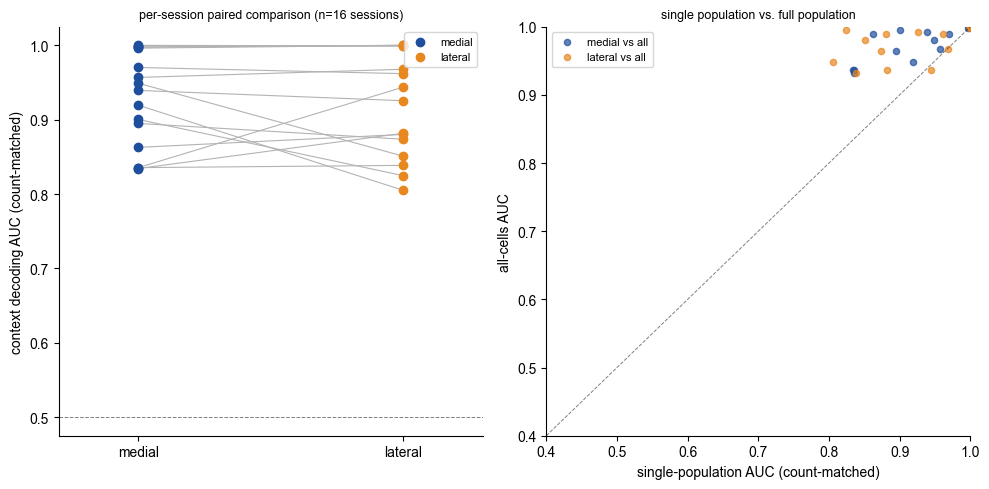

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
for _, row in method1_df.iterrows():
    ax.plot([0, 1], [row['auc_medial'], row['auc_lateral']], color='0.7', linewidth=0.8, zorder=1)
ax.scatter(np.zeros(len(method1_df)), method1_df['auc_medial'], color=MEDIAL_COLOR, zorder=2, label='medial')
ax.scatter(np.ones(len(method1_df)), method1_df['auc_lateral'], color=LATERAL_COLOR, zorder=2, label='lateral')
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['medial', 'lateral']); ax.set_xlim(-0.3, 1.3)
ax.set_ylabel('context decoding AUC (count-matched)')
ax.set_title(f'per-session paired comparison (n={len(method1_df)} sessions)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

stat, p = wilcoxon(method1_df['auc_medial'], method1_df['auc_lateral'])
n_medial_higher = int((method1_df['auc_medial'] > method1_df['auc_lateral']).sum())
print(f'wilcoxon (medial vs lateral, count-matched AUC): stat={stat}, p={p:.4f}, '
      f'medial higher in {n_medial_higher}/{len(method1_df)} sessions')

ax = axes[1]
ax.scatter(method1_df['auc_medial'], method1_df['auc_all'], color=MEDIAL_COLOR, s=20, alpha=0.7, label='medial vs all')
ax.scatter(method1_df['auc_lateral'], method1_df['auc_all'], color=LATERAL_COLOR, s=20, alpha=0.7, label='lateral vs all')
lims = [0.4, 1.0]
ax.plot(lims, lims, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('single-population AUC (count-matched)'); ax.set_ylabel('all-cells AUC')
ax.set_title('single population vs. full population', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_method1.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Method 2: ablation order curves

For each session, rank cells by `coord_CCFs_x` (descending = medial to
lateral). Two removal orders: strip from the lateral end first (leaving
progressively more purely-medial populations) vs. strip from the medial
end first (leaving progressively more purely-lateral populations). At
each of 10 fraction-of-cells-remaining checkpoints, refit the same
cross-validated decoder on exactly the cells remaining -- both orders
leave the *same number* of cells at each checkpoint by construction, so
this is inherently count-matched at every point, without needing
subsampling.

In [7]:
FRACTIONS = np.linspace(1.0, 0.1, 10)

def ablation_curve(rates, y, order_idx):
    n_total = len(order_idx)
    aucs = []
    for frac in FRACTIONS:
        n_keep = max(2, int(round(frac * n_total)))
        keep = order_idx[:n_keep]
        aucs.append(cv_auc(rates[:, keep], y))
    return np.array(aucs)

lateral_first_curves, medial_first_curves = [], []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    rates, y = c['rates'], c['contexts']
    meta = session_data[(mouse, day)]['meta']
    order_medial_to_lateral = np.argsort(-meta['coord_CCFs_x'].values)   # most medial first

    lateral_first_curves.append(ablation_curve(rates, y, order_medial_to_lateral))          # keep medial-most first -> lateral stripped first
    medial_first_curves.append(ablation_curve(rates, y, order_medial_to_lateral[::-1]))     # keep lateral-most first -> medial stripped first

lateral_first_curves = np.array(lateral_first_curves)
medial_first_curves = np.array(medial_first_curves)
print(f'{lateral_first_curves.shape[0]} sessions x {lateral_first_curves.shape[1]} fraction checkpoints')

16 sessions x 10 fraction checkpoints


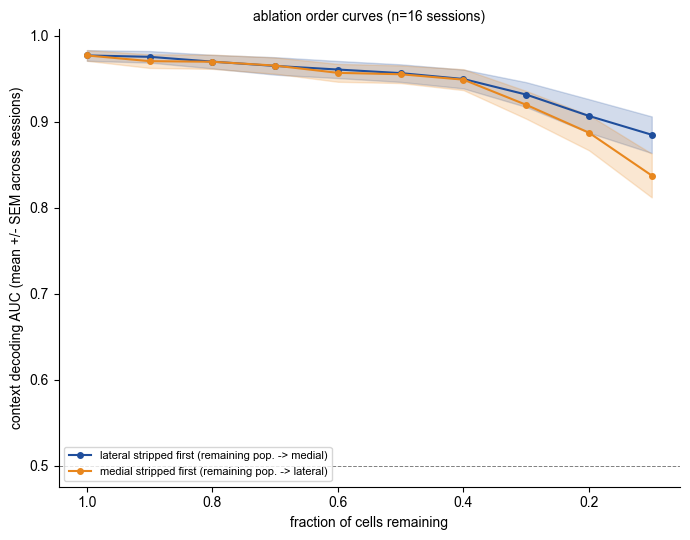

at ~60% cells remaining: wilcoxon p=0.4265, lateral-first-curve higher (i.e. medial-biased remaining pop. wins) in 8/16 sessions


In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for curves, color, label in [(lateral_first_curves, MEDIAL_COLOR, 'lateral stripped first (remaining pop. -> medial)'),
                              (medial_first_curves, LATERAL_COLOR, 'medial stripped first (remaining pop. -> lateral)')]:
    mean_curve = np.nanmean(curves, axis=0)
    sem_curve = np.nanstd(curves, axis=0) / np.sqrt(np.sum(~np.isnan(curves), axis=0))
    ax.plot(FRACTIONS, mean_curve, color=color, marker='o', markersize=4, label=label)
    ax.fill_between(FRACTIONS, mean_curve - sem_curve, mean_curve + sem_curve, color=color, alpha=0.2, linewidth=0, edgecolor='none')

ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('fraction of cells remaining')
ax.set_ylabel('context decoding AUC (mean +/- SEM across sessions)')
ax.invert_xaxis()
ax.set_title(f'ablation order curves (n={len(included_sessions)} sessions)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_method2.pdf'), dpi=200, bbox_inches='tight')
plt.show()

diff_at_50pct = lateral_first_curves[:, 4] - medial_first_curves[:, 4]   # index 4 -> fraction ~0.6, closest to mid-range
stat, p = wilcoxon(lateral_first_curves[:, 4], medial_first_curves[:, 4])
print(f'at ~{FRACTIONS[4]:.0%} cells remaining: wilcoxon p={p:.4f}, '
      f'lateral-first-curve higher (i.e. medial-biased remaining pop. wins) in '
      f'{int((diff_at_50pct>0).sum())}/{len(diff_at_50pct)} sessions')

## Method 3: single-cell context selectivity, medial vs. lateral

Per unit, ROC-AUC for discriminating rz1 vs. rz2 from that cell's own
trial-averaged firing rate (0.5 = no selectivity; distance from 0.5 in
either direction = selective, direction = which context it prefers).
`|AUC-0.5|` is compared between medial and lateral cells -- this is a
decoder-free, single-cell-level complement to methods 1-2.

In [9]:
cell_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    rates, y, is_medial = c['rates'], c['contexts'], c['is_medial']
    regions = session_data[(mouse, day)]['meta']['brain_region'].values
    for i2 in range(rates.shape[1]):
        auc = roc_auc_score(y, rates[:, i2])
        cell_rows.append(dict(mouse=mouse, day=day, side='medial' if is_medial[i2] else 'lateral',
                               region=regions[i2], auc=auc, selectivity=abs(auc - 0.5)))
cell_df = pd.DataFrame(cell_rows)
print(f'{len(cell_df)} cells total ({(cell_df.side=="medial").sum()} medial, {(cell_df.side=="lateral").sum()} lateral)')

3486 cells total (2248 medial, 1238 lateral)


pooled mann-whitney U (medial vs lateral |AUC-0.5|): stat=1400702, p=0.7466
per-session wilcoxon (median selectivity, medial vs lateral): stat=53.0, p=0.4637, medial higher in 10/16 sessions


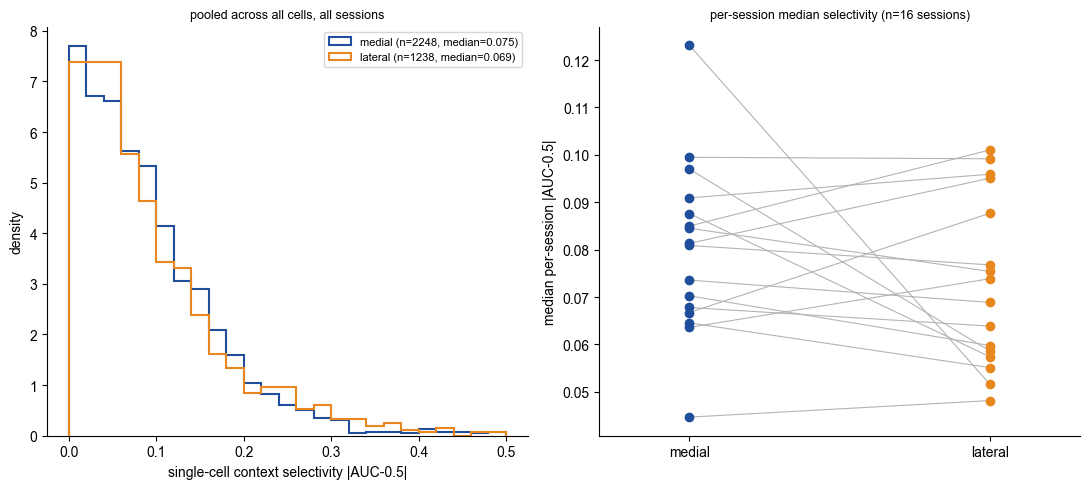

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
bins = np.linspace(0, 0.5, 26)
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    vals = cell_df[cell_df.side == side]['selectivity']
    ax.hist(vals, bins=bins, density=True, histtype='step', color=color, linewidth=1.5,
            label=f'{side} (n={len(vals)}, median={vals.median():.3f})')
ax.set_xlabel('single-cell context selectivity |AUC-0.5|')
ax.set_ylabel('density')
ax.set_title('pooled across all cells, all sessions', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

stat, p = mannwhitneyu(cell_df[cell_df.side == 'medial']['selectivity'],
                        cell_df[cell_df.side == 'lateral']['selectivity'])
print(f'pooled mann-whitney U (medial vs lateral |AUC-0.5|): stat={stat:.0f}, p={p:.4g}')

ax = axes[1]
session_medians = cell_df.groupby(['mouse', 'day', 'side'])['selectivity'].median().unstack('side')
for _, row in session_medians.iterrows():
    ax.plot([0, 1], [row['medial'], row['lateral']], color='0.7', linewidth=0.8, zorder=1)
ax.scatter(np.zeros(len(session_medians)), session_medians['medial'], color=MEDIAL_COLOR, zorder=2)
ax.scatter(np.ones(len(session_medians)), session_medians['lateral'], color=LATERAL_COLOR, zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['medial', 'lateral']); ax.set_xlim(-0.3, 1.3)
ax.set_ylabel('median per-session |AUC-0.5|')
ax.set_title(f'per-session median selectivity (n={len(session_medians)} sessions)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

stat2, p2 = wilcoxon(session_medians['medial'], session_medians['lateral'])
n_med_higher = int((session_medians['medial'] > session_medians['lateral']).sum())
print(f'per-session wilcoxon (median selectivity, medial vs lateral): stat={stat2}, p={p2:.4f}, '
      f'medial higher in {n_med_higher}/{len(session_medians)} sessions')

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_method3.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Controlling for the speed confound

Context decoding above could partly (or entirely) reflect the fact that
mice may simply run at different speeds in `rz1` vs. `rz2` -- many
entorhinal/hippocampal-formation cells are speed-modulated, so a systematic
speed difference between contexts could inflate decoding accuracy without
reflecting a genuine context-identity code.

**A single trial-mean speed isn't enough to check this.** `rz1`'s reward
zone is at 92cm and `rz2`'s is at 122cm, so the two contexts' speed
profiles necessarily decelerate at *different track positions* -- a
scalar trial-average can be identical while the underlying spatial
*shape* differs completely, and it's exactly that shape difference that
speed-modulated cells could pick up on. So the checks below control for
speed **position-bin by position-bin across the full trial**, not just
its trial-average level:

1. **Does the speed profile's *shape* actually differ between contexts?**
   -- plot the mean position-binned speed profile for `rz1` vs. `rz2`.
2. **How well does the full speed profile *shape* decode context?** -- a
   behaviour-only baseline using the top PCs of the position-binned speed
   profile (not just its mean), same cross-validation scheme as the
   neural decoders.
3. **Redo methods 1 and 3 on speed-residualized firing rates** -- for
   each cell, at *every position bin separately*, regress that bin's
   trial-to-trial rate against that bin's trial-to-trial speed and keep
   the residual, then average back to a trial-level residual rate. This
   removes any position-locked speed modulation anywhere along the
   track, not just an overall speed-level effect, before repeating the
   medial-vs-lateral comparisons.

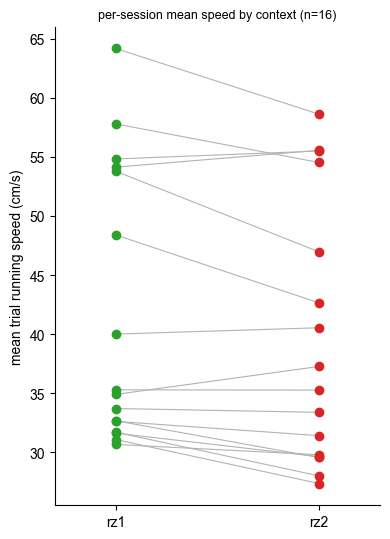

mean trial speed: rz1=41.7cm/s, rz2=39.7cm/s
per-session paired wilcoxon (rz1 vs rz2 speed): stat=23.0, p=0.01825, rz2 faster in 4/16 sessions


In [11]:
speed_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    speed, y = c['speed'], c['contexts']
    speed_rows.append(dict(mouse=mouse, day=day,
                            speed_rz1=speed[y == 0].mean(), speed_rz2=speed[y == 1].mean()))
speed_df = pd.DataFrame(speed_rows)
speed_df['diff'] = speed_df['speed_rz2'] - speed_df['speed_rz1']

fig, ax = plt.subplots(figsize=(4, 5.5))
for _, row in speed_df.iterrows():
    ax.plot([0, 1], [row['speed_rz1'], row['speed_rz2']], color='0.7', linewidth=0.8, zorder=1)
ax.scatter(np.zeros(len(speed_df)), speed_df['speed_rz1'], color=CTX1_COLOR, zorder=2, label='rz1')
ax.scatter(np.ones(len(speed_df)), speed_df['speed_rz2'], color=CTX2_COLOR, zorder=2, label='rz2')
ax.set_xticks([0, 1]); ax.set_xticklabels(['rz1', 'rz2']); ax.set_xlim(-0.3, 1.3)
ax.set_ylabel('mean trial running speed (cm/s)')
ax.set_title(f'per-session mean speed by context (n={len(speed_df)})', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_speed_by_context.pdf'), dpi=200, bbox_inches='tight')
plt.show()

stat, p = wilcoxon(speed_df['speed_rz1'], speed_df['speed_rz2'])
print(f'mean trial speed: rz1={speed_df.speed_rz1.mean():.1f}cm/s, rz2={speed_df.speed_rz2.mean():.1f}cm/s')
print(f'per-session paired wilcoxon (rz1 vs rz2 speed): stat={stat}, p={p:.4g}, '
      f'rz2 faster in {int((speed_df["diff"] > 0).sum())}/{len(speed_df)} sessions')

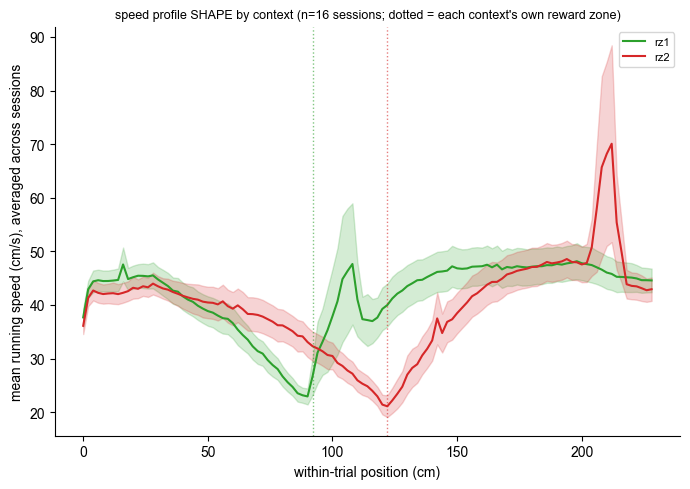

In [12]:
n_bins_per_trial = int(TL / BS)
pos_centers = np.arange(n_bins_per_trial) * BS

profile_rows_rz1, profile_rows_rz2 = [], []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    profile, y = c['speed_profile'], c['contexts']
    profile_rows_rz1.append(np.nanmean(profile[y == 0], axis=0))
    profile_rows_rz2.append(np.nanmean(profile[y == 1], axis=0))
mean_profile_rz1 = np.nanmean(profile_rows_rz1, axis=0)
mean_profile_rz2 = np.nanmean(profile_rows_rz2, axis=0)
sem_profile_rz1 = np.nanstd(profile_rows_rz1, axis=0) / np.sqrt(len(profile_rows_rz1))
sem_profile_rz2 = np.nanstd(profile_rows_rz2, axis=0) / np.sqrt(len(profile_rows_rz2))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pos_centers, mean_profile_rz1, color=CTX1_COLOR, label='rz1')
ax.fill_between(pos_centers, mean_profile_rz1 - sem_profile_rz1, mean_profile_rz1 + sem_profile_rz1,
                 color=CTX1_COLOR, alpha=0.2, linewidth=0, edgecolor='none')
ax.plot(pos_centers, mean_profile_rz2, color=CTX2_COLOR, label='rz2')
ax.fill_between(pos_centers, mean_profile_rz2 - sem_profile_rz2, mean_profile_rz2 + sem_profile_rz2,
                 color=CTX2_COLOR, alpha=0.2, linewidth=0, edgecolor='none')
ax.axvline(92, color=CTX1_COLOR, linestyle=':', linewidth=1, alpha=0.6)
ax.axvline(122, color=CTX2_COLOR, linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('within-trial position (cm)')
ax.set_ylabel('mean running speed (cm/s), averaged across sessions')
ax.set_title(f'speed profile SHAPE by context (n={len(included_sessions)} sessions; '
             f'dotted = each context\'s own reward zone)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_speed_profile_shape.pdf'), dpi=200, bbox_inches='tight')
plt.show()

### Speed profile by block and trial type, per animal

Blocks are runs of 20 consecutive same-context trials, alternating rz1/rz2 through the
session. Which context leads varies between sessions, so blocks are indexed by their
ordinal position *within* a context rather than by raw block number -- "rz1 block 1",
"rz1 block 2", and so on -- and averaged across that animal's sessions.

Colour = context (green rz1 / red rz2), saturation = block order through the session,
line style = trial type (solid beaconed / dashed non-beaconed). Dotted verticals mark
each context's reward zone. This shows whether the speed profile is stable across the
session or drifts block to block, and whether the cued and uncued trials differ in shape
-- both of which matter for the speed-confound controls above.


In [ ]:
# --- average speed profile per block and per trial type, one panel per animal ---
from matplotlib.lines import Line2D

mice_in = sorted({m for m, _ in included_sessions})
pos_centers = np.arange(int(TL / BS)) * BS
RZ_CENTRE = {0: 92, 1: 122}          # rz1 / rz2 reward zone, as in the plot above

# (mouse, context, block ordinal within that context, trial type) -> list of trial profiles.
# Blocks alternate rz1/rz2, but which context leads varies by session, so index blocks by
# their ordinal position WITHIN a context rather than by raw block number.
prof = {}
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    blk, ctx, typ, sp = c['blocks'], c['contexts'], c['types'], c['speed_profile']
    seen = {0: 0, 1: 0}
    for b in np.unique(blk):
        in_b = blk == b
        cc = int(ctx[in_b][0])
        k = seen[cc]; seen[cc] += 1
        for tt in ('b', 'nb'):
            sel = in_b & (typ == tt)
            if sel.sum():
                prof.setdefault((mouse, cc, k, tt), []).append(sp[sel])

max_ord = max(k for (_, _, k, _) in prof) + 1
cmaps = {0: plt.cm.Greens, 1: plt.cm.Reds}
lstyle = {'b': '-', 'nb': '--'}

fig, axes = plt.subplots(1, len(mice_in), figsize=(10, 3.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, mouse in zip(axes, mice_in):
    for (m, cc, k, tt), chunks in sorted(prof.items()):
        if m != mouse:
            continue
        mean_p = np.nanmean(np.vstack(chunks), axis=0)
        shade = 0.35 + 0.60 * (k / max(max_ord - 1, 1))
        ax.plot(pos_centers, mean_p, color=cmaps[cc](shade), linestyle=lstyle[tt], linewidth=1.0)
    for cc, x in RZ_CENTRE.items():
        ax.axvline(x, color=(CTX1_COLOR if cc == 0 else CTX2_COLOR),
                   linestyle=':', linewidth=1, alpha=0.6)
    n_sess = sum(1 for mm, _ in included_sessions if mm == mouse)
    ax.set_title(f'{mouse} ({n_sess} sessions)', fontsize=9)
    ax.set_xlabel('position (cm)')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('speed (cm/s)')

# Display limit. A small fraction of position bins carry non-physiological speed estimates
# (up to ~2900 cm/s), concentrated at the rz1 reward zone (~96-108cm) and near the track end
# (~208-212cm) -- bins where the mouse stops, so few samples survive the `moving` (>3cm/s)
# epoch and the occupancy-normalised estimate becomes unstable. Clipping the axis here only
# affects display; see the note below for the effect on the profiles themselves.
YMAX = 100
axes[0].set_ylim(0, YMAX)
n_clipped = sum(int((np.nanmean(np.vstack(ch), axis=0) > YMAX).sum()) for ch in prof.values())
n_points = sum(len(pos_centers) for _ in prof)
print(f'{n_clipped}/{n_points} plotted points ({100*n_clipped/n_points:.2f}%) above the {YMAX} cm/s display limit')

handles = [Line2D([], [], color=CTX1_COLOR, label='rz1 (familiar)'),
           Line2D([], [], color=CTX2_COLOR, label='rz2 (novel)'),
           Line2D([], [], color='0.3', linestyle='-', label='beaconed'),
           Line2D([], [], color='0.3', linestyle='--', label='non-beaconed')]
axes[-1].legend(handles=handles, fontsize=7, frameon=False,
                loc='upper left', bbox_to_anchor=(1.02, 1.0))
fig.suptitle('Speed profile by block and trial type '
             '(colour saturation = block order through session)', fontsize=9, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_speed_profile_by_block_and_type.pdf'),
            dpi=200, bbox_inches='tight')
plt.show()

for mouse in mice_in:
    nb_rz1 = max((k for (m, cc, k, _) in prof if m == mouse and cc == 0), default=-1) + 1
    nb_rz2 = max((k for (m, cc, k, _) in prof if m == mouse and cc == 1), default=-1) + 1
    print(f'{mouse}: up to {nb_rz1} rz1 blocks and {nb_rz2} rz2 blocks per session')


## Cross-block encoding transfer: does a cell's position model survive a context switch?

Blocks are 20-trial design units alternating rz1/rz2 (rz1 always leads; `block = (trial_number-1)//20`).
That layout gives a clean transfer test. For each cell we fit a position+speed encoding model on the
trials of one block and score it on the trials of another, in three conditions:

| condition | train -> test | holds constant | what it measures |
|---|---|---|---|
| `within` | block *b* first half -> second half | context, time | ceiling: how repeatable is the model at all |
| `same`   | block *b* -> block *b+2*             | context        | cost of elapsed time / drift alone |
| `diff`   | block *b* -> block *b+1*             | time (approx)  | cost of time **plus** a context switch |

The quantity of interest is `same - diff`: the drop attributable to the context switch **over and above**
the drop from two blocks of elapsed time. Without the `same` baseline a `diff` drop is just drift.

Design choices that matter:
- **Every condition trains on 10 trials and tests on 10 trials.** Unequal training data would make the
  ceiling meaningless (a half-block model looks worse purely for being fit on less data).
- **pR2 is scored against the *test* block's own mean rate.** Using the training block's mean would score
  a simple firing-rate change between contexts as a loss of tuning, which is a different claim entirely.
- **Speed is a covariate**, clipped at 100 cm/s. Speed profiles differ by context, so without it a
  transfer failure could just be a speed difference; the clip guards the reward-zone artifact noted above.
- Both directions of every pair are run, so rz1->rz2 and rz2->rz1 are both represented and block-order
  effects can be checked rather than assumed.


In [ ]:
# --- cross-block encoding transfer (position + speed -> firing rate) ---
from xgboost import XGBRegressor

HALF = 10                 # trials used for train and for test in EVERY condition
MIN_BLOCK_TRIALS = 2 * HALF
SPEED_CLIP = 100.0        # cm/s -- see the speed-artifact note above
XGB_KW = dict(objective='count:poisson', n_estimators=100, max_depth=3,
              learning_rate=0.1, subsample=0.8, verbosity=0, n_jobs=1)
TRANSFER_CSV = os.path.join(CACHE_DIR, 'block_transfer_pr2.csv')


def pois_pr2(y, yhat, ynull):
    """Poisson pseudo-R2 (matches spatial_manifolds.mlencoding).

    `ynull` must be the TEST set's own mean rate. Scoring against the training
    block's mean would count a pure firing-rate change between contexts as a loss
    of tuning, which is not what this analysis is asking."""
    eps = np.spacing(1)
    L1 = np.sum(y * np.log(eps + yhat) - yhat)
    L0 = np.sum(y * np.log(eps + ynull) - ynull)
    LS = np.sum(y * np.log(eps + y) - y)
    d = LS - L0
    return np.nan if abs(d) < 1e-12 else 1 - (LS - L1) / d


def _design(c, trial_idx):
    """(n_trials x N_COARSE) rows of [position bin, speed] for the given trials."""
    S = np.clip(np.nan_to_num(c['speed_profile_coarse'][trial_idx]), 0, SPEED_CLIP)
    return np.column_stack([np.tile(np.arange(N_COARSE), len(trial_idx)), S.ravel()])


def _fit_score(Xtr, ytr, Xte, yte):
    if ytr.sum() <= 0 or yte.sum() <= 0:
        return np.nan
    m = XGBRegressor(**XGB_KW).fit(Xtr, ytr)
    return pois_pr2(yte, np.clip(m.predict(Xte), 1e-6, None), np.mean(yte))


if os.path.exists(TRANSFER_CSV):
    transfer_df = pd.read_csv(TRANSFER_CSV)
    print(f'loaded cached transfer results: {len(transfer_df)} rows')
else:
    rows, t0 = [], time.time()
    for mouse, day in included_sessions:
        c = rate_cache[(mouse, day)]
        P, blk, ismed = c['rate_profile_coarse'], c['blocks'], c['is_medial']
        n_units = P.shape[2]

        # first / second half-block trial indices, for blocks with a full 20 trials
        halves = {}
        for b in np.unique(blk):
            idx = np.where(blk == b)[0]
            if len(idx) >= MIN_BLOCK_TRIALS:
                halves[int(b)] = (idx[:HALF], idx[HALF:2 * HALF])
        usable = sorted(halves)

        # (condition, train trials, test trials, train block, test block)
        jobs = []
        for b in usable:
            jobs.append(('within', halves[b][0], halves[b][1], b, b))
            jobs.append(('within', halves[b][1], halves[b][0], b, b))
            for off, cond in ((1, 'diff'), (2, 'same')):
                if b + off in usable:
                    jobs.append((cond, halves[b][0], halves[b + off][0], b, b + off))
                    jobs.append((cond, halves[b + off][0], halves[b][0], b + off, b))

        cache_X = {}
        for cond, tr, te, ba, bb in jobs:
            for key, ix in ((id(tr), tr), (id(te), te)):
                if key not in cache_X:
                    cache_X[key] = _design(c, ix)
            Xtr, Xte = cache_X[id(tr)], cache_X[id(te)]
            for u in range(n_units):
                r = _fit_score(Xtr, P[tr][:, :, u].ravel(), Xte, P[te][:, :, u].ravel())
                if np.isnan(r):
                    continue
                rows.append(dict(mouse=mouse, day=day, unit=u, cond=cond,
                                 train_blk=ba, test_blk=bb,
                                 ctx_from='rz1' if ba % 2 == 0 else 'rz2',
                                 medial=bool(ismed[u]), pr2=r))
        print(f'{mouse} D{day}: {len(usable)} full blocks, {len(jobs)} transfers x {n_units} cells '
              f'[{time.time() - t0:.0f}s]', flush=True)

    transfer_df = pd.DataFrame(rows)
    transfer_df.to_csv(TRANSFER_CSV, index=False)
    print(f'done in {time.time() - t0:.0f}s -- {len(transfer_df)} rows -> {TRANSFER_CSV}')

print(transfer_df.groupby('cond')['pr2'].describe()[['count', 'mean', '50%']])


In [ ]:
# --- summarise cross-block transfer ---
# per cell x condition, averaging over whichever block pairs contributed
cell_cond = (transfer_df.groupby(['mouse', 'day', 'unit', 'medial', 'cond'])['pr2']
             .mean().unstack('cond'))
cell_cond = cell_cond.dropna(subset=['within', 'same', 'diff'])

# LEARNABILITY FILTER. For ~80% of cells the position+speed model does not beat a
# constant-rate null even within a block (pR2 < 0) -- trial-to-trial variability swamps
# spatial tuning at this training-set size. This is not an XGBoost artifact: a plain
# per-bin rate-map model performs the same. For those cells the condition differences
# measure how badly each fit overfits, not how the code transfers, so they are excluded.
# Note the selection is on `within` only, so the same-vs-diff contrast -- the quantity of
# interest -- is not biased by it. within-vs-anything comparisons ARE inflated by it.
LEARNABLE = cell_cond['within'] > 0
print(f'{int(LEARNABLE.sum())}/{len(cell_cond)} cells ({100 * LEARNABLE.mean():.1f}%) have a '
      f'within-block model that beats the null; restricting to those.')
cell_cond = cell_cond[LEARNABLE]
cell_cond['context_cost'] = cell_cond['same'] - cell_cond['diff']   # the quantity of interest
cell_cond['time_cost'] = cell_cond['within'] - cell_cond['same']    # drift over 2 blocks, same context
cc = cell_cond.reset_index()

# session-level medians (cells within a session are not independent -- all stats are per session)
sess_ml = cc.groupby(['mouse', 'day', 'medial'])[
    ['within', 'same', 'diff', 'context_cost', 'time_cost']].median().reset_index()
sess = cc.groupby(['mouse', 'day'])[
    ['within', 'same', 'diff', 'context_cost', 'time_cost']].median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))

# A: the three conditions
ax = axes[0]
conds = ['within', 'same', 'diff']
for _, r in sess.iterrows():
    ax.plot(range(3), [r[c] for c in conds], color='0.75', lw=0.8, zorder=1)
for i, c in enumerate(conds):
    ax.scatter([i] * len(sess), sess[c], color=ALL_COLOR, s=18, zorder=2)
ax.set_xticks(range(3))
ax.set_xticklabels(['within\n(ceiling)', 'same ctx\n(b -> b+2)', 'diff ctx\n(b -> b+1)'], fontsize=8)
ax.set_ylabel('pR$^2$ (session median)')
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_title('encoding-model transfer', fontsize=9)

# B: context cost, medial vs lateral
ax = axes[1]
med = sess_ml[sess_ml.medial].set_index(['mouse', 'day'])['context_cost']
lat = sess_ml[~sess_ml.medial].set_index(['mouse', 'day'])['context_cost']
common = med.index.intersection(lat.index)
for k in common:
    ax.plot([0, 1], [med[k], lat[k]], color='0.75', lw=0.8, zorder=1)
ax.scatter([0] * len(common), med[common], color=MEDIAL_COLOR, s=18, zorder=2)
ax.scatter([1] * len(common), lat[common], color=LATERAL_COLOR, s=18, zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['medial', 'lateral'], fontsize=8)
ax.set_xlim(-0.35, 1.35)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_ylabel('context cost  (same $-$ diff)')
ax.set_title('cost of a context switch', fontsize=9)

# C: direction check -- rz1->rz2 vs rz2->rz1
ax = axes[2]
dirc = (transfer_df[transfer_df.cond.isin(['same', 'diff'])]
        .groupby(['mouse', 'day', 'unit', 'ctx_from', 'cond'])['pr2'].mean().unstack('cond').dropna())
dirc['context_cost'] = dirc['same'] - dirc['diff']
dsess = dirc.reset_index().groupby(['mouse', 'day', 'ctx_from'])['context_cost'].median().unstack('ctx_from').dropna()
for _, r in dsess.iterrows():
    ax.plot([0, 1], [r['rz1'], r['rz2']], color='0.75', lw=0.8, zorder=1)
ax.scatter([0] * len(dsess), dsess['rz1'], color=CTX1_COLOR, s=18, zorder=2)
ax.scatter([1] * len(dsess), dsess['rz2'], color=CTX2_COLOR, s=18, zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['rz1 $\\rightarrow$ rz2', 'rz2 $\\rightarrow$ rz1'], fontsize=8)
ax.set_xlim(-0.35, 1.35)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_ylabel('context cost')
ax.set_title('transfer direction', fontsize=9)

for a in axes:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_block_transfer.pdf'), dpi=200, bbox_inches='tight')
plt.show()

n = len(sess)
print(f'{n} sessions, {len(cc)} cells with all three conditions\n')
print('session medians:')
for c in ['within', 'same', 'diff']:
    print(f'  {c:>7}: {sess[c].mean():+.4f}')
print()
s, p = wilcoxon(sess['within'], sess['same'])
print(f'within vs same (cost of 2 blocks elapsed, same context): stat={s}, p={p:.4g}, '
      f'median drop {sess["time_cost"].median():+.4f}')
s, p = wilcoxon(sess['same'], sess['diff'])
print(f'same vs diff  (cost of the CONTEXT SWITCH itself):       stat={s}, p={p:.4g}, '
      f'median drop {sess["context_cost"].median():+.4f}')
print(f'  context cost > 0 in {int((sess.context_cost > 0).sum())}/{n} sessions')
print()
s, p = wilcoxon(med[common], lat[common])
print(f'context cost, medial vs lateral: stat={s}, p={p:.4g}  '
      f'(medial {med[common].median():+.4f}, lateral {lat[common].median():+.4f}, '
      f'medial larger in {int((med[common] > lat[common]).sum())}/{len(common)} sessions)')
s, p = wilcoxon(dsess['rz1'], dsess['rz2'])
print(f'context cost, rz1->rz2 vs rz2->rz1: stat={s}, p={p:.4g}  '
      f'({dsess["rz1"].median():+.4f} vs {dsess["rz2"].median():+.4f})')


## 2x2: context switch vs cue removal (pooled-block design)

The block-pair version above showed the limiting factor is training-set size: with 10 trials the
position+speed model beats a constant-rate null in only ~19% of cells, and a plain rate-map model does
no better, so this is a property of the data rather than of XGBoost. This version fixes that by pooling
**all** full blocks of a context, which also removes the lag problem for free -- rz1 and rz2 blocks
alternate throughout the session, so pooled rz1 and pooled rz2 trials are interleaved in time and the
context comparison is time-matched by construction. No lag interpolation needed.

Each cell gets four training sets -- (rz1,beaconed), (rz1,non-beaconed), (rz2,beaconed),
(rz2,non-beaconed) -- of 20 trials each, and each is tested on 20 held-out trials from:

| condition | test set | differs from training in |
|---|---|---|
| `cue`     | same context, other trial type | cue only |
| `context` | other context, same trial type | context only |
| `both`    | other context, other trial type | both |

Results are averaged over the four training sets, so no single context or trial type drives the score.
All 16 sessions supply >= 20 trials in every one of the four combinations.

**Learnability** is measured separately, as 3-fold CV *within* the training combination using all of its
trials (21-76 depending on session). It is a filter, not a condition, so it does not need to be
sample-size matched -- and using more trials makes it a better filter.

**Additivity** is the extra question this design can answer: if `both` is approximately `cue + context`,
the two factors act independently on the code. If `both` is much less than their sum, they interact.


In [ ]:
# --- 2x2 factorial, pooled-block design ---
N_TR = N_TE = 20                   # trials for train and for each test set
N_CV = 3                           # folds for the within-combo learnability screen
XGB_KW2 = dict(XGB_KW, n_estimators=80)
FACT2_CSV = os.path.join(CACHE_DIR, 'block_transfer_factorial2_pr2.csv')
COMBOS = [('rz1', 'b'), ('rz1', 'nb'), ('rz2', 'b'), ('rz2', 'nb')]


def _other(v, which):
    if which == 'ctx':
        return 'rz2' if v == 'rz1' else 'rz1'
    return 'nb' if v == 'b' else 'b'


if os.path.exists(FACT2_CSV):
    fact_df = pd.read_csv(FACT2_CSV)
    print(f'loaded cached factorial results: {len(fact_df)} rows')
else:
    rows, t0 = [], time.time()
    for mouse, day in included_sessions:
        c = rate_cache[(mouse, day)]
        P, blk, ismed, typ = (c['rate_profile_coarse'], c['blocks'],
                              c['is_medial'], c['types'])
        n_units = P.shape[2]

        full = [b for b in np.unique(blk) if (blk == b).sum() >= 20]
        keep = np.isin(blk, full)
        pool = {}
        for ctx, par in (('rz1', 0), ('rz2', 1)):
            for tt in ('b', 'nb'):
                pool[(ctx, tt)] = np.where(keep & (blk % 2 == par) & (typ == tt))[0]
        if any(len(v) < N_TR for v in pool.values()):
            print(f'{mouse} D{day}: skipped, a combo has < {N_TR} trials')
            continue

        Xc = {}
        def X_for(ix):
            k = ix.tobytes()
            if k not in Xc:
                Xc[k] = _design(c, ix)
            return Xc[k]

        jobs = []          # (cond, train idx, test idx, train ctx, train type)
        for ctx, tt in COMBOS:
            tr = pool[(ctx, tt)][:N_TR]
            jobs.append(('cue',     tr, pool[(ctx, _other(tt, 'type'))][:N_TE], ctx, tt))
            jobs.append(('context', tr, pool[(_other(ctx, 'ctx'), tt)][:N_TE], ctx, tt))
            jobs.append(('both',    tr, pool[(_other(ctx, 'ctx'), _other(tt, 'type'))][:N_TE], ctx, tt))

        for cond, tr, te, ctx, tt in jobs:
            Xtr, Xte = X_for(tr), X_for(te)
            for u in range(n_units):
                r = _fit_score(Xtr, P[tr][:, :, u].ravel(), Xte, P[te][:, :, u].ravel())
                if not np.isnan(r):
                    rows.append(dict(mouse=mouse, day=day, unit=u, cond=cond,
                                     train_ctx=ctx, train_type=tt,
                                     medial=bool(ismed[u]), pr2=r))

        # learnability: k-fold CV inside each training combo, using all of its trials
        for ctx, tt in COMBOS:
            ix = pool[(ctx, tt)]
            folds = np.array_split(np.arange(len(ix)), N_CV)
            for k in range(N_CV):
                te_i = ix[folds[k]]
                tr_i = ix[np.concatenate([folds[j] for j in range(N_CV) if j != k])]
                Xtr, Xte = X_for(tr_i), X_for(te_i)
                for u in range(n_units):
                    r = _fit_score(Xtr, P[tr_i][:, :, u].ravel(), Xte, P[te_i][:, :, u].ravel())
                    if not np.isnan(r):
                        rows.append(dict(mouse=mouse, day=day, unit=u, cond='learnable',
                                         train_ctx=ctx, train_type=tt,
                                         medial=bool(ismed[u]), pr2=r))
        print(f'{mouse} D{day}: {len(full)} full blocks, {n_units} cells '
              f'[{time.time() - t0:.0f}s]', flush=True)

    fact_df = pd.DataFrame(rows)
    fact_df.to_csv(FACT2_CSV, index=False)
    print(f'done in {time.time() - t0:.0f}s -- {len(fact_df)} rows -> {FACT2_CSV}')

print(fact_df.groupby('cond')['pr2'].agg(['count', 'mean', 'median']).round(4))


In [ ]:
# --- summarise the pooled-block 2x2 ---
lrn = (fact_df[fact_df.cond == 'learnable']
       .groupby(['mouse', 'day', 'unit', 'medial'])['pr2'].mean().rename('learnable'))
eff = (fact_df[fact_df.cond != 'learnable']
       .groupby(['mouse', 'day', 'unit', 'medial', 'cond'])['pr2'].mean().unstack('cond'))
fc = eff.join(lrn, how='inner').dropna().reset_index()

LEARNABLE = fc['learnable'] > 0
print(f'{int(LEARNABLE.sum())}/{len(fc)} cells ({100 * LEARNABLE.mean():.1f}%) are learnable '
      f'(within-combo CV pR2 > 0) -- compare with 19.2% under the 10-trial design')
fc = fc[LEARNABLE].copy()

fc['cue_cost'] = fc['learnable'] - fc['cue']
fc['ctx_cost'] = fc['learnable'] - fc['context']
fc['both_cost'] = fc['learnable'] - fc['both']
fc['interaction'] = (fc['cue_cost'] + fc['ctx_cost']) - fc['both_cost']   # >0 = sub-additive

S = fc.groupby(['mouse', 'day'])[['learnable', 'cue', 'context', 'both',
                                   'cue_cost', 'ctx_cost', 'both_cost',
                                   'interaction']].median().reset_index()
Sml = fc.groupby(['mouse', 'day', 'medial'])[['cue_cost', 'ctx_cost']].median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))

ax = axes[0]
conds = ['learnable', 'cue', 'context', 'both']
for _, r in S.iterrows():
    ax.plot(range(4), [r[c] for c in conds], color='0.75', lw=0.8, zorder=1)
for i, cnd in enumerate(conds):
    ax.scatter([i] * len(S), S[cnd], color=ALL_COLOR, s=16, zorder=2)
ax.set_xticks(range(4))
ax.set_xticklabels(['within\n(CV)', 'cue\nswapped', 'context\nswitched', 'both'], fontsize=8)
ax.set_ylabel('pR$^2$ (session median)'); ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_title('transfer by condition', fontsize=9)

ax = axes[1]
for _, r in S.iterrows():
    ax.plot([0, 1], [r['cue_cost'], r['ctx_cost']], color='0.75', lw=0.8, zorder=1)
ax.scatter([0] * len(S), S['cue_cost'], color=ALL_COLOR, s=16, zorder=2)
ax.scatter([1] * len(S), S['ctx_cost'], color=ALL_COLOR, s=16, zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['cue\nremoval', 'context\nswitch'], fontsize=8)
ax.set_xlim(-0.35, 1.35); ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_ylabel('pR$^2$ cost'); ax.set_title('what breaks the model?', fontsize=9)

ax = axes[2]
for j, col in enumerate(['cue_cost', 'ctx_cost']):
    m = Sml[Sml.medial].set_index(['mouse', 'day'])[col]
    l = Sml[~Sml.medial].set_index(['mouse', 'day'])[col]
    k = m.index.intersection(l.index)
    off = j * 2
    for kk in k:
        ax.plot([off, off + 1], [m[kk], l[kk]], color='0.85', lw=0.7, zorder=1)
    ax.scatter([off] * len(k), m[k], color=MEDIAL_COLOR, s=16, zorder=2)
    ax.scatter([off + 1] * len(k), l[k], color=LATERAL_COLOR, s=16, zorder=2)
ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(['med', 'lat', 'med', 'lat'], fontsize=8)
ax.set_xlabel('cue removal        context switch', fontsize=8)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_ylabel('pR$^2$ cost'); ax.set_title('medial vs lateral', fontsize=9)

for a in axes:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_block_transfer_2x2.pdf'), dpi=200, bbox_inches='tight')
plt.show()

n = len(S)
print(f'\n{len(fc)} learnable cells, {n} sessions\n')
for cnd in conds:
    print(f'  {cnd:>10}: {S[cnd].median():+.4f}')
print()
s, p = wilcoxon(S['learnable'], S['cue'])
print(f'cue removal   : cost {S.cue_cost.median():+.4f}, p={p:.4g}, >0 in {int((S.cue_cost > 0).sum())}/{n}')
s, p = wilcoxon(S['learnable'], S['context'])
print(f'context switch: cost {S.ctx_cost.median():+.4f}, p={p:.4g}, >0 in {int((S.ctx_cost > 0).sum())}/{n}')
s, p = wilcoxon(S['cue_cost'], S['ctx_cost'])
print(f'cue vs context: p={p:.4g}  (context larger in {int((S.ctx_cost > S.cue_cost).sum())}/{n} sessions)')
s, p = wilcoxon(S['interaction'], np.zeros(n))
print(f'sub-additivity (cue+ctx - both): {S.interaction.median():+.4f}, p={p:.4g}')
print()
for col, lab in [('cue_cost', 'cue removal'), ('ctx_cost', 'context switch')]:
    m = Sml[Sml.medial].set_index(['mouse', 'day'])[col]
    l = Sml[~Sml.medial].set_index(['mouse', 'day'])[col]
    k = m.index.intersection(l.index)
    s, p = wilcoxon(m[k], l[k])
    print(f'{lab:>15}, medial vs lateral: p={p:.4g} '
          f'(med {m[k].median():+.4f}, lat {l[k].median():+.4f}, '
          f'med>lat {int((m[k] > l[k]).sum())}/{len(k)})')


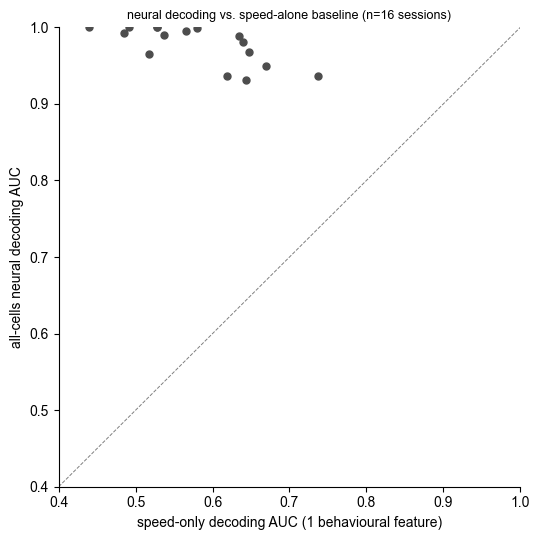

speed-only AUC: mean=0.579, median=0.573
all-cells neural AUC: mean=0.977, median=0.989
neural AUC > speed-only AUC in 16/16 sessions


In [13]:
speed_only_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    auc_speed_only = cv_auc(c['speed'].reshape(-1, 1), c['contexts'])
    speed_only_rows.append(dict(mouse=mouse, day=day, auc_speed_only=auc_speed_only))
speed_only_df = pd.DataFrame(speed_only_rows)
merged = method1_df.merge(speed_only_df, on=['mouse', 'day'])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(merged['auc_speed_only'], merged['auc_all'], color=ALL_COLOR, s=25)
lims = [0.4, 1.0]
ax.plot(lims, lims, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('speed-only decoding AUC (1 behavioural feature)')
ax.set_ylabel('all-cells neural decoding AUC')
ax.set_title(f'neural decoding vs. speed-alone baseline (n={len(merged)} sessions)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_speed_baseline.pdf'), dpi=200, bbox_inches='tight')
plt.show()

print(f'speed-only AUC: mean={merged.auc_speed_only.mean():.3f}, median={merged.auc_speed_only.median():.3f}')
print(f'all-cells neural AUC: mean={merged.auc_all.mean():.3f}, median={merged.auc_all.median():.3f}')
print(f'neural AUC > speed-only AUC in {int((merged.auc_all > merged.auc_speed_only).sum())}/{len(merged)} sessions')

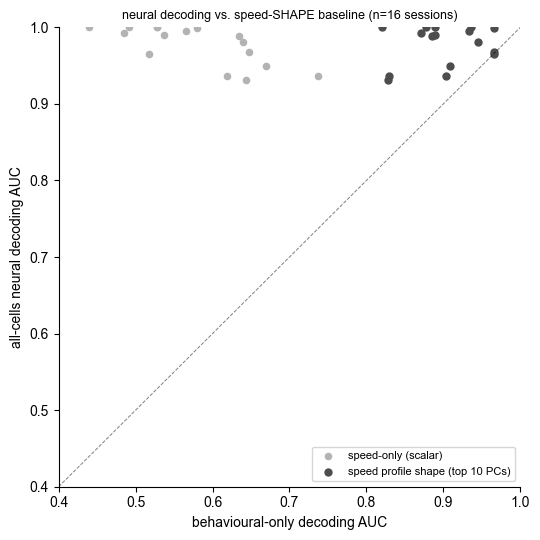

speed-shape (PCA) AUC: mean=0.901, median=0.896
vs. speed-only (scalar) AUC: mean=0.579
all-cells neural AUC: mean=0.977
neural AUC > speed-shape AUC in 15/16 sessions


In [14]:
speed_shape_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    profile = np.nan_to_num(c['speed_profile'])
    n_comp = min(10, profile.shape[0] - 1, profile.shape[1])
    pcs = PCA(n_components=n_comp, random_state=0).fit_transform(StandardScaler().fit_transform(profile))
    c['speed_pcs'] = pcs   # cached for reuse by the XGBoost section below
    auc_shape = cv_auc(pcs, c['contexts'])
    speed_shape_rows.append(dict(mouse=mouse, day=day, auc_speed_shape=auc_shape))
speed_shape_df = pd.DataFrame(speed_shape_rows)
merged_shape = merged.merge(speed_shape_df, on=['mouse', 'day'])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(merged_shape['auc_speed_only'], merged_shape['auc_all'], color='0.7', s=20,
           label='speed-only (scalar)')
ax.scatter(merged_shape['auc_speed_shape'], merged_shape['auc_all'], color=ALL_COLOR, s=25,
           label='speed profile shape (top 10 PCs)')
lims = [0.4, 1.0]
ax.plot(lims, lims, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('behavioural-only decoding AUC'); ax.set_ylabel('all-cells neural decoding AUC')
ax.set_title(f'neural decoding vs. speed-SHAPE baseline (n={len(merged_shape)} sessions)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_speed_shape_baseline.pdf'), dpi=200, bbox_inches='tight')
plt.show()

print(f'speed-shape (PCA) AUC: mean={merged_shape.auc_speed_shape.mean():.3f}, '
      f'median={merged_shape.auc_speed_shape.median():.3f}')
print(f'vs. speed-only (scalar) AUC: mean={merged_shape.auc_speed_only.mean():.3f}')
print(f'all-cells neural AUC: mean={merged_shape.auc_all.mean():.3f}')
print(f'neural AUC > speed-shape AUC in {int((merged_shape.auc_all > merged_shape.auc_speed_shape).sum())}/{len(merged_shape)} sessions')

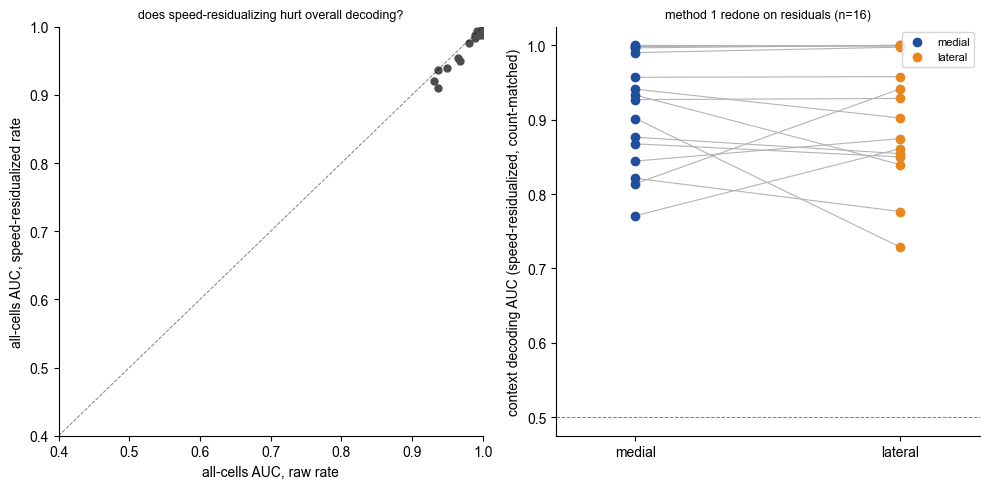

all-cells AUC: raw mean=0.977, speed-residualized mean=0.971
wilcoxon (medial vs lateral, speed-residualized, count-matched AUC): stat=62.0, p=0.7820, medial higher in 8/16 sessions


In [15]:
method1_resid_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    rates_r, y, is_medial = c['residual_rates'], c['contexts'], c['is_medial']
    n_match = min(is_medial.sum(), (~is_medial).sum())

    auc_all_r = cv_auc(rates_r, y)
    auc_medial_r = matched_subsample_auc(rates_r, y, is_medial, 'medial', n_match)
    auc_lateral_r = matched_subsample_auc(rates_r, y, is_medial, 'lateral', n_match)
    method1_resid_rows.append(dict(mouse=mouse, day=day, auc_all_resid=auc_all_r,
                                    auc_medial_resid=auc_medial_r, auc_lateral_resid=auc_lateral_r))

method1_resid_df = pd.DataFrame(method1_resid_rows)
method1_compare = method1_df.merge(method1_resid_df, on=['mouse', 'day'])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.scatter(method1_compare['auc_all'], method1_compare['auc_all_resid'], color=ALL_COLOR, s=25)
lims = [0.4, 1.0]
ax.plot(lims, lims, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('all-cells AUC, raw rate'); ax.set_ylabel('all-cells AUC, speed-residualized rate')
ax.set_title('does speed-residualizing hurt overall decoding?', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
for _, row in method1_resid_df.iterrows():
    ax.plot([0, 1], [row['auc_medial_resid'], row['auc_lateral_resid']], color='0.7', linewidth=0.8, zorder=1)
ax.scatter(np.zeros(len(method1_resid_df)), method1_resid_df['auc_medial_resid'], color=MEDIAL_COLOR, zorder=2, label='medial')
ax.scatter(np.ones(len(method1_resid_df)), method1_resid_df['auc_lateral_resid'], color=LATERAL_COLOR, zorder=2, label='lateral')
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['medial', 'lateral']); ax.set_xlim(-0.3, 1.3)
ax.set_ylabel('context decoding AUC (speed-residualized, count-matched)')
ax.set_title(f'method 1 redone on residuals (n={len(method1_resid_df)})', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_method1_speed_controlled.pdf'), dpi=200, bbox_inches='tight')
plt.show()

print(f'all-cells AUC: raw mean={method1_compare.auc_all.mean():.3f}, '
      f'speed-residualized mean={method1_compare.auc_all_resid.mean():.3f}')
stat, p = wilcoxon(method1_resid_df['auc_medial_resid'], method1_resid_df['auc_lateral_resid'])
n_medial_higher = int((method1_resid_df['auc_medial_resid'] > method1_resid_df['auc_lateral_resid']).sum())
print(f'wilcoxon (medial vs lateral, speed-residualized, count-matched AUC): stat={stat}, p={p:.4f}, '
      f'medial higher in {n_medial_higher}/{len(method1_resid_df)} sessions')

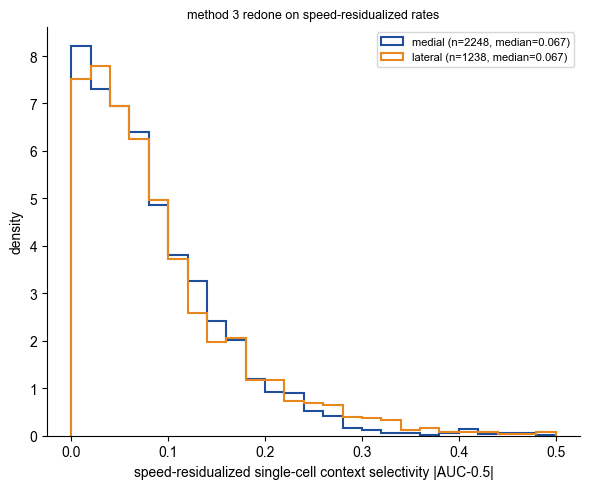

pooled mann-whitney U (medial vs lateral |AUC-0.5|, speed-residualized): stat=1369770, p=0.4446
per-session wilcoxon (median selectivity, medial vs lateral, speed-residualized): stat=55.0, p=0.5282, medial higher in 9/16 sessions


In [16]:
cell_resid_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    rates_r, y, is_medial = c['residual_rates'], c['contexts'], c['is_medial']
    for i in range(rates_r.shape[1]):
        auc = roc_auc_score(y, rates_r[:, i])
        cell_resid_rows.append(dict(mouse=mouse, day=day, side='medial' if is_medial[i] else 'lateral',
                                     selectivity=abs(auc - 0.5)))
cell_resid_df = pd.DataFrame(cell_resid_rows)

fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(0, 0.5, 26)
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    vals = cell_resid_df[cell_resid_df.side == side]['selectivity']
    ax.hist(vals, bins=bins, density=True, histtype='step', color=color, linewidth=1.5,
            label=f'{side} (n={len(vals)}, median={vals.median():.3f})')
ax.set_xlabel('speed-residualized single-cell context selectivity |AUC-0.5|')
ax.set_ylabel('density')
ax.set_title('method 3 redone on speed-residualized rates', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_method3_speed_controlled.pdf'), dpi=200, bbox_inches='tight')
plt.show()

stat, p = mannwhitneyu(cell_resid_df[cell_resid_df.side == 'medial']['selectivity'],
                        cell_resid_df[cell_resid_df.side == 'lateral']['selectivity'])
print(f'pooled mann-whitney U (medial vs lateral |AUC-0.5|, speed-residualized): stat={stat:.0f}, p={p:.4g}')

session_medians_r = cell_resid_df.groupby(['mouse', 'day', 'side'])['selectivity'].median().unstack('side')
stat2, p2 = wilcoxon(session_medians_r['medial'], session_medians_r['lateral'])
n_med_higher = int((session_medians_r['medial'] > session_medians_r['lateral']).sum())
print(f'per-session wilcoxon (median selectivity, medial vs lateral, speed-residualized): stat={stat2}, p={p2:.4f}, '
      f'medial higher in {n_med_higher}/{len(session_medians_r)} sessions')

## Context selectivity beyond speed (XGBoost)

The bin-wise residualization above assumes each cell's speed-tuning is
*linear* at each position bin. XGBoost makes no such assumption, so it's
a useful complementary check: for each cell, in each session, compare a
gradient-boosted classifier given **only** the speed-profile shape (top
10 PCs, same features as the behavioural baseline above) against one
given **that plus the cell's own trial-mean rate**. The improvement in
cross-validated AUC from adding the cell (`delta_auc = auc_full -
auc_speed_only`) is a per-cell "context information beyond speed" score
-- a decoder-based, non-linear analogue of the linear residualization,
at single-cell resolution. The speed-only baseline is identical for
every cell within a session, so it's fit once per session, not once per
cell.

In [17]:
def cv_auc_xgb(X, y, cv_folds=CV_FOLDS, seed=0):
    if len(np.unique(y)) < 2:
        return np.nan
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    probs = np.zeros(len(y))
    for train_idx, test_idx in skf.split(X, y):
        model = xgb.XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.3,
                                   subsample=0.8, colsample_bytree=0.8,
                                   eval_metric='logloss', random_state=seed, verbosity=0)
        model.fit(X[train_idx], y[train_idx])
        probs[test_idx] = model.predict_proba(X[test_idx])[:, 1]
    return roc_auc_score(y, probs)

t0 = time.time()
xgb_cell_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    speed_pcs, rates, y, is_medial = c['speed_pcs'], c['rates'], c['contexts'], c['is_medial']
    auc_speed_only_xgb = cv_auc_xgb(speed_pcs, y)
    for i in range(rates.shape[1]):
        X_full = np.column_stack([speed_pcs, rates[:, i]])
        auc_full_xgb = cv_auc_xgb(X_full, y)
        xgb_cell_rows.append(dict(mouse=mouse, day=day, side='medial' if is_medial[i] else 'lateral',
                                   auc_speed_only_xgb=auc_speed_only_xgb, auc_full_xgb=auc_full_xgb,
                                   delta_auc=auc_full_xgb - auc_speed_only_xgb))
xgb_cell_df = pd.DataFrame(xgb_cell_rows)
print(f'done in {time.time()-t0:.0f}s, {len(xgb_cell_df)} cells '
      f'({(xgb_cell_df.side=="medial").sum()} medial, {(xgb_cell_df.side=="lateral").sum()} lateral)')
print(f'mean speed-only (XGBoost) AUC across sessions: {xgb_cell_df.groupby(["mouse","day"]).auc_speed_only_xgb.first().mean():.3f}')
print(f'delta_auc (cell beyond speed): mean={xgb_cell_df.delta_auc.mean():.4f}, '
      f'median={xgb_cell_df.delta_auc.median():.4f}, frac>0={100*(xgb_cell_df.delta_auc>0).mean():.1f}%')

done in 520s, 3486 cells (2248 medial, 1238 lateral)
mean speed-only (XGBoost) AUC across sessions: 0.900
delta_auc (cell beyond speed): mean=0.0052, median=0.0027, frac>0=60.7%


pooled mann-whitney U (medial vs lateral delta_auc): stat=1513554, p=1.774e-05
per-session wilcoxon (median delta_auc, medial vs lateral): stat=55.0, p=0.5282, medial higher in 10/16 sessions


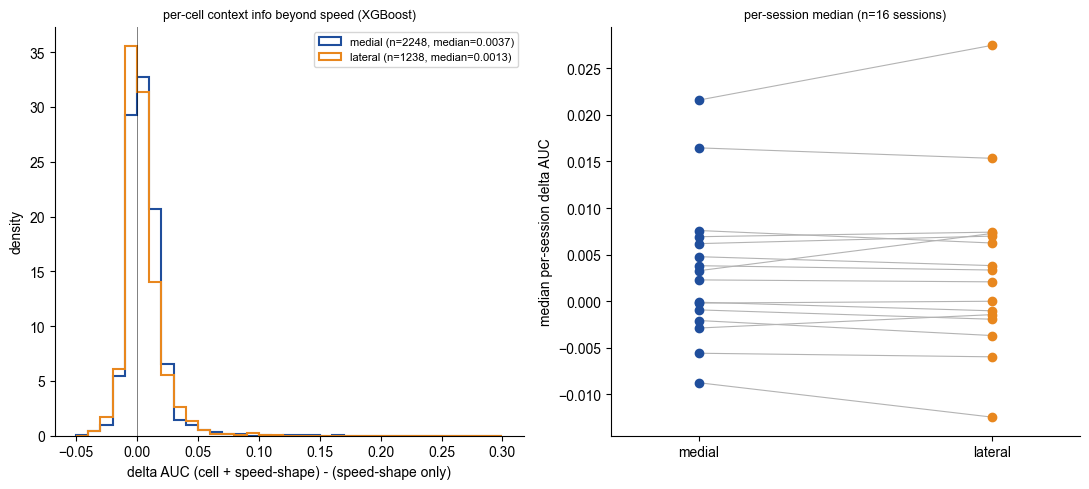

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
bins = np.linspace(-0.05, 0.3, 36)
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    vals = xgb_cell_df[xgb_cell_df.side == side]['delta_auc']
    ax.hist(vals, bins=bins, density=True, histtype='step', color=color, linewidth=1.5,
            label=f'{side} (n={len(vals)}, median={vals.median():.4f})')
ax.axvline(0, color='k', linewidth=0.7, alpha=0.5)
ax.set_xlabel('delta AUC (cell + speed-shape) - (speed-shape only)')
ax.set_ylabel('density')
ax.set_title('per-cell context info beyond speed (XGBoost)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

stat, p = mannwhitneyu(xgb_cell_df[xgb_cell_df.side == 'medial']['delta_auc'],
                        xgb_cell_df[xgb_cell_df.side == 'lateral']['delta_auc'])
print(f'pooled mann-whitney U (medial vs lateral delta_auc): stat={stat:.0f}, p={p:.4g}')

ax = axes[1]
xgb_session_medians = xgb_cell_df.groupby(['mouse', 'day', 'side'])['delta_auc'].median().unstack('side')
for _, row in xgb_session_medians.iterrows():
    ax.plot([0, 1], [row['medial'], row['lateral']], color='0.7', linewidth=0.8, zorder=1)
ax.scatter(np.zeros(len(xgb_session_medians)), xgb_session_medians['medial'], color=MEDIAL_COLOR, zorder=2)
ax.scatter(np.ones(len(xgb_session_medians)), xgb_session_medians['lateral'], color=LATERAL_COLOR, zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['medial', 'lateral']); ax.set_xlim(-0.3, 1.3)
ax.set_ylabel('median per-session delta AUC')
ax.set_title(f'per-session median (n={len(xgb_session_medians)} sessions)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

stat2, p2 = wilcoxon(xgb_session_medians['medial'], xgb_session_medians['lateral'])
n_med_higher = int((xgb_session_medians['medial'] > xgb_session_medians['lateral']).sum())
print(f'per-session wilcoxon (median delta_auc, medial vs lateral): stat={stat2}, p={p2:.4f}, '
      f'medial higher in {n_med_higher}/{len(xgb_session_medians)} sessions')

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_xgboost_beyond_speed.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Does the firing rate PROFILE discriminate context beyond speed?

Everything above used each cell's **trial-mean** firing rate, which
collapses the whole trial to one number and is therefore blind to any
spatial restructuring between contexts -- a cell that completely
relocates its firing field between `rz1` and `rz2` but keeps its mean
rate scores AUC=0.5 and looks unselective. That is the more interesting
context signal in this circuit, and the mean-rate measure cannot see it.

This section uses the **position-binned firing rate profile across the
trial** (23 bins x 10cm) instead, and asks the question in the form that
controls for behaviour: does adding a cell's spatial profile improve
context decoding *over and above* the animal's speed profile across the
same trial (also 23 x 10cm bins)? XGBoost throughout, so no linearity
assumption about how speed maps to rate, and the speed baseline is
identical for every cell in a session (fit once per session).

- **Population level:** speed profile alone vs. population profiles alone
  vs. both together. The population's profiles are PCA-reduced *inside
  each CV fold* (no leakage across the train/test split).
- **Per cell:** `delta_auc = AUC(speed profile + this cell's profile) -
  AUC(speed profile alone)`, then compared medial vs. lateral.

In [19]:
def cv_auc_pop(y, speed_c=None, pop_flat=None, n_pca=20, seed=0):
    """Cross-validated AUC with any PCA fit INSIDE each fold (no leakage).
    speed_c: (n_trials, N_COARSE) raw features, passed through un-reduced.
    pop_flat: (n_trials, N_COARSE*n_units) population profiles, PCA-reduced."""
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    probs = np.zeros(len(y))
    for tr, te in skf.split(np.zeros(len(y)), y):
        blocks_tr, blocks_te = [], []
        if speed_c is not None:
            blocks_tr.append(speed_c[tr]); blocks_te.append(speed_c[te])
        if pop_flat is not None:
            k = min(n_pca, len(tr) - 1, pop_flat.shape[1])
            p = PCA(n_components=k, random_state=seed)
            blocks_tr.append(p.fit_transform(pop_flat[tr]))
            blocks_te.append(p.transform(pop_flat[te]))
        X_tr, X_te = np.column_stack(blocks_tr), np.column_stack(blocks_te)
        m = xgb.XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.3,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=seed, verbosity=0)
        m.fit(X_tr, y[tr])
        probs[te] = m.predict_proba(X_te)[:, 1]
    return roc_auc_score(y, probs)

pop_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    y, speed_c, rate_c = c['contexts'], c['speed_profile_coarse'], c['rate_profile_coarse']
    pop_flat = rate_c.reshape(rate_c.shape[0], -1)          # (n_trials, N_COARSE * n_units)
    auc_speed = cv_auc_pop(y, speed_c=speed_c)
    auc_pop = cv_auc_pop(y, pop_flat=pop_flat)
    auc_both = cv_auc_pop(y, speed_c=speed_c, pop_flat=pop_flat)
    pop_rows.append(dict(mouse=mouse, day=day, n_cells=rate_c.shape[2],
                          auc_speed_profile=auc_speed, auc_pop_profile=auc_pop,
                          auc_both=auc_both, delta_over_speed=auc_both - auc_speed))
pop_profile_df = pd.DataFrame(pop_rows)
print(pop_profile_df.to_string(index=False))
print()
print(f'speed profile alone:        mean AUC={pop_profile_df.auc_speed_profile.mean():.3f}')
print(f'population profiles alone:  mean AUC={pop_profile_df.auc_pop_profile.mean():.3f}')
print(f'both together:              mean AUC={pop_profile_df.auc_both.mean():.3f}')
stat, p = wilcoxon(pop_profile_df['auc_both'], pop_profile_df['auc_speed_profile'])
print(f'both vs speed-alone: wilcoxon stat={stat}, p={p:.4g}, '
      f'improved in {int((pop_profile_df.delta_over_speed > 0).sum())}/{len(pop_profile_df)} sessions '
      f'(mean delta={pop_profile_df.delta_over_speed.mean():+.4f})')

mouse  day  n_cells  auc_speed_profile  auc_pop_profile  auc_both  delta_over_speed
  M25   26      212           0.972069         0.954368  0.976092          0.004023
  M25   28      273           0.987500         0.987885  0.992692          0.005192
  M25   30      299           0.968041         0.988247  0.982990          0.014948
  M26   20      243           0.914676         0.985882  0.983817          0.069141
  M26   21      286           0.937241         0.981734  0.983588          0.046347
  M26   22      289           0.966842         0.983123  0.985784          0.018943
  M28   24       79           0.934409         0.967742  0.984409          0.050000
  M28   26      174           0.936885         0.967008  0.963525          0.026639
  M28   27      193           0.854098         0.918579  0.922404          0.068306
  M28   28      194           0.880328         0.968306  0.951093          0.070765
  M28   29      211           0.906762         0.901434  0.916189          0

In [20]:
t0 = time.time()
prof_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    y, speed_c, rate_c, is_medial = (c['contexts'], c['speed_profile_coarse'],
                                      c['rate_profile_coarse'], c['is_medial'])
    auc_speed = cv_auc_xgb(speed_c, y)                      # baseline, once per session
    for i in range(rate_c.shape[2]):
        X_full = np.column_stack([speed_c, rate_c[:, :, i]])
        auc_full = cv_auc_xgb(X_full, y)
        prof_rows.append(dict(mouse=mouse, day=day,
                               side='medial' if is_medial[i] else 'lateral',
                               auc_speed=auc_speed, auc_full=auc_full,
                               delta_profile=auc_full - auc_speed))
prof_cell_df = pd.DataFrame(prof_rows)
print(f'done in {time.time()-t0:.0f}s, {len(prof_cell_df)} cells')
print(f'delta_profile (cell profile beyond speed profile): '
      f'mean={prof_cell_df.delta_profile.mean():+.4f}, median={prof_cell_df.delta_profile.median():+.4f}, '
      f'frac>0={100*(prof_cell_df.delta_profile>0).mean():.1f}%')
print()
print('for comparison, the trial-MEAN version from the earlier section:')
print(f'delta_auc (mean rate beyond speed PCs): mean={xgb_cell_df.delta_auc.mean():+.4f}, '
      f'median={xgb_cell_df.delta_auc.median():+.4f}, frac>0={100*(xgb_cell_df.delta_auc>0).mean():.1f}%')

done in 504s, 3486 cells
delta_profile (cell profile beyond speed profile): mean=+0.0022, median=-0.0003, frac>0=48.7%

for comparison, the trial-MEAN version from the earlier section:
delta_auc (mean rate beyond speed PCs): mean=+0.0052, median=+0.0027, frac>0=60.7%


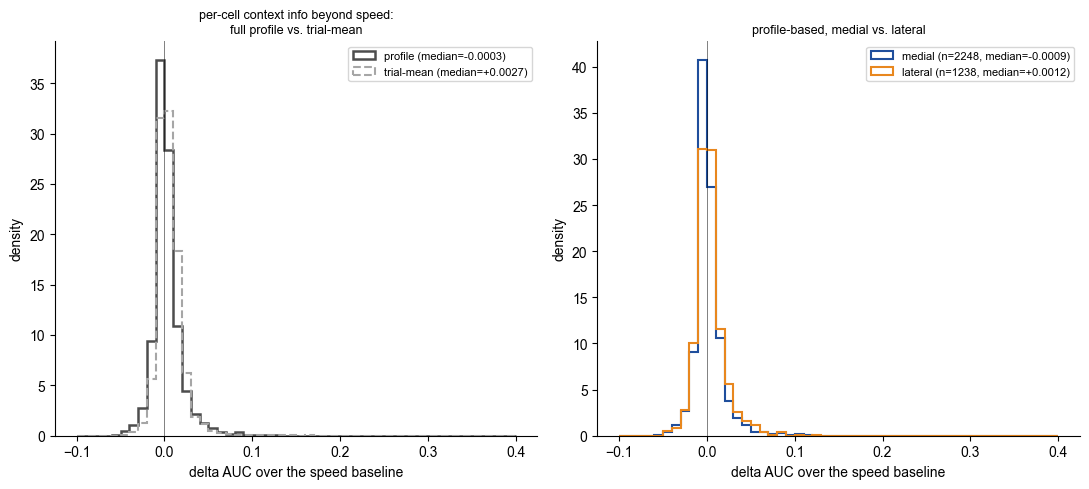

pooled mann-whitney U (medial vs lateral delta_profile): stat=1282636, p=0.0001289
per-session wilcoxon (median delta_profile, medial vs lateral): stat=23.0, p=0.0182, medial higher in 2/16 sessions

per-session medians:
side        lateral    medial
mouse day                    
M25   26  -0.002874 -0.002989
      28  -0.003077 -0.004038
      30   0.003763 -0.000309
M26   20  -0.002958 -0.005190
      21  -0.001527 -0.003162
      22   0.001576  0.000228
M28   24  -0.013710 -0.000067
      26  -0.005328 -0.003996
      27   0.016940  0.015027
      28   0.013661  0.010246
      29  -0.011885 -0.015369
M29   24   0.005625  0.004583
      26   0.005574  0.005068
      27   0.011651  0.006019
      28   0.007104  0.006831
      29   0.002525  0.002475


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
bins = np.linspace(-0.1, 0.4, 51)
ax.hist(prof_cell_df['delta_profile'], bins=bins, density=True, histtype='step',
        color=ALL_COLOR, linewidth=1.8, label=f'profile (median={prof_cell_df.delta_profile.median():+.4f})')
ax.hist(xgb_cell_df['delta_auc'], bins=bins, density=True, histtype='step',
        color='0.65', linewidth=1.5, linestyle='--',
        label=f'trial-mean (median={xgb_cell_df.delta_auc.median():+.4f})')
ax.axvline(0, color='k', linewidth=0.7, alpha=0.5)
ax.set_xlabel('delta AUC over the speed baseline')
ax.set_ylabel('density')
ax.set_title('per-cell context info beyond speed:\nfull profile vs. trial-mean', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

ax = axes[1]
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    vals = prof_cell_df[prof_cell_df.side == side]['delta_profile']
    ax.hist(vals, bins=bins, density=True, histtype='step', color=color, linewidth=1.5,
            label=f'{side} (n={len(vals)}, median={vals.median():+.4f})')
ax.axvline(0, color='k', linewidth=0.7, alpha=0.5)
ax.set_xlabel('delta AUC over the speed baseline')
ax.set_ylabel('density')
ax.set_title('profile-based, medial vs. lateral', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_profile_beyond_speed.pdf'), dpi=200, bbox_inches='tight')
plt.show()

stat, p = mannwhitneyu(prof_cell_df[prof_cell_df.side == 'medial']['delta_profile'],
                        prof_cell_df[prof_cell_df.side == 'lateral']['delta_profile'])
print(f'pooled mann-whitney U (medial vs lateral delta_profile): stat={stat:.0f}, p={p:.4g}')

prof_session = prof_cell_df.groupby(['mouse', 'day', 'side'])['delta_profile'].median().unstack('side')
stat2, p2 = wilcoxon(prof_session['medial'], prof_session['lateral'])
n_med = int((prof_session['medial'] > prof_session['lateral']).sum())
print(f'per-session wilcoxon (median delta_profile, medial vs lateral): stat={stat2}, p={p2:.4f}, '
      f'medial higher in {n_med}/{len(prof_session)} sessions')
print()
print('per-session medians:')
print(prof_session.to_string())

### A fairer per-cell instrument: PCA-compressed profiles

The per-cell test above is dimensionality-penalized -- it adds 23 noisy
features for one cell on top of 23 speed features, with only ~120-340
trials, so real signal gets diluted and the metric performs *worse* than
the 1-feature trial-mean version. That is a property of the test, not of
the cells.

Fairer version: compress each cell's profile to its top few principal
components before adding it to the speed baseline, so the profile's
shape information survives but the feature count does not blow up. The
PCA is fit **inside each CV fold** (train split only), so nothing leaks
across the train/test boundary. Everything else is unchanged.

In [22]:
N_CELL_PCA = 4   # components per cell profile (from 23 coarse position bins)

def cv_auc_cell_pca(speed_c, cell_profile, y, n_pca=N_CELL_PCA, seed=0):
    """AUC for [speed profile + this cell's PCA-compressed profile], PCA fit per fold."""
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    probs = np.zeros(len(y))
    for tr, te in skf.split(np.zeros(len(y)), y):
        k = min(n_pca, len(tr) - 1, cell_profile.shape[1])
        p = PCA(n_components=k, random_state=seed)
        Z_tr = p.fit_transform(cell_profile[tr])
        Z_te = p.transform(cell_profile[te])
        m = xgb.XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.3,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=seed, verbosity=0)
        m.fit(np.column_stack([speed_c[tr], Z_tr]), y[tr])
        probs[te] = m.predict_proba(np.column_stack([speed_c[te], Z_te]))[:, 1]
    return roc_auc_score(y, probs)

t0 = time.time()
pca_rows = []
for mouse, day in included_sessions:
    c = rate_cache[(mouse, day)]
    y, speed_c, rate_c, is_medial = (c['contexts'], c['speed_profile_coarse'],
                                      c['rate_profile_coarse'], c['is_medial'])
    mean_rate = c['rates'].mean(axis=0)          # per-cell mean firing rate, for the confound check
    auc_speed = cv_auc_xgb(speed_c, y)
    for i in range(rate_c.shape[2]):
        auc_full = cv_auc_cell_pca(speed_c, rate_c[:, :, i], y)
        pca_rows.append(dict(mouse=mouse, day=day,
                              side='medial' if is_medial[i] else 'lateral',
                              mean_rate=mean_rate[i],
                              delta_pca=auc_full - auc_speed))
pca_cell_df = pd.DataFrame(pca_rows)
print(f'done in {time.time()-t0:.0f}s, {len(pca_cell_df)} cells')
print()
print('per-cell context info beyond speed -- three instruments:')
print(f'  trial-mean (1 feature):      mean={xgb_cell_df.delta_auc.mean():+.4f}, '
      f'median={xgb_cell_df.delta_auc.median():+.4f}, frac>0={100*(xgb_cell_df.delta_auc>0).mean():.1f}%')
print(f'  full profile (23 features):  mean={prof_cell_df.delta_profile.mean():+.4f}, '
      f'median={prof_cell_df.delta_profile.median():+.4f}, frac>0={100*(prof_cell_df.delta_profile>0).mean():.1f}%')
print(f'  profile PCA ({N_CELL_PCA} features):     mean={pca_cell_df.delta_pca.mean():+.4f}, '
      f'median={pca_cell_df.delta_pca.median():+.4f}, frac>0={100*(pca_cell_df.delta_pca>0).mean():.1f}%')
print()
stat, p = mannwhitneyu(pca_cell_df[pca_cell_df.side=='medial']['delta_pca'],
                        pca_cell_df[pca_cell_df.side=='lateral']['delta_pca'])
print(f'pooled mann-whitney U (medial vs lateral delta_pca): stat={stat:.0f}, p={p:.4g}')
pca_session = pca_cell_df.groupby(['mouse','day','side'])['delta_pca'].median().unstack('side')
stat2, p2 = wilcoxon(pca_session['medial'], pca_session['lateral'])
n_med = int((pca_session['medial'] > pca_session['lateral']).sum())
print(f'per-session wilcoxon (median delta_pca, medial vs lateral): stat={stat2}, p={p2:.4f}, '
      f'medial higher in {n_med}/{len(pca_session)} sessions')

done in 525s, 3486 cells

per-cell context info beyond speed -- three instruments:
  trial-mean (1 feature):      mean=+0.0052, median=+0.0027, frac>0=60.7%
  full profile (23 features):  mean=+0.0022, median=-0.0003, frac>0=48.7%
  profile PCA (4 features):     mean=+0.0027, median=+0.0007, frac>0=52.8%

pooled mann-whitney U (medial vs lateral delta_pca): stat=1299568, p=0.001224
per-session wilcoxon (median delta_pca, medial vs lateral): stat=52.0, p=0.4332, medial higher in 7/16 sessions


mean firing rate (Hz) by side:
          count      mean       50%
side                               
lateral  1238.0  8.248748  6.118423
medial   2248.0  8.147750  5.104814
pooled mann-whitney (medial vs lateral mean rate): p=0.0002211
per-session wilcoxon (median rate): p=0.0739, medial higher in 4/16

does delta depend on firing rate? spearman rho=+0.126, p=7.326e-14

RATE-MATCHED (session x rate-quartile strata, n=64): wilcoxon p=0.7482, medial higher in 30/64 strata
  median delta -- medial=+0.00062, lateral=+0.00108


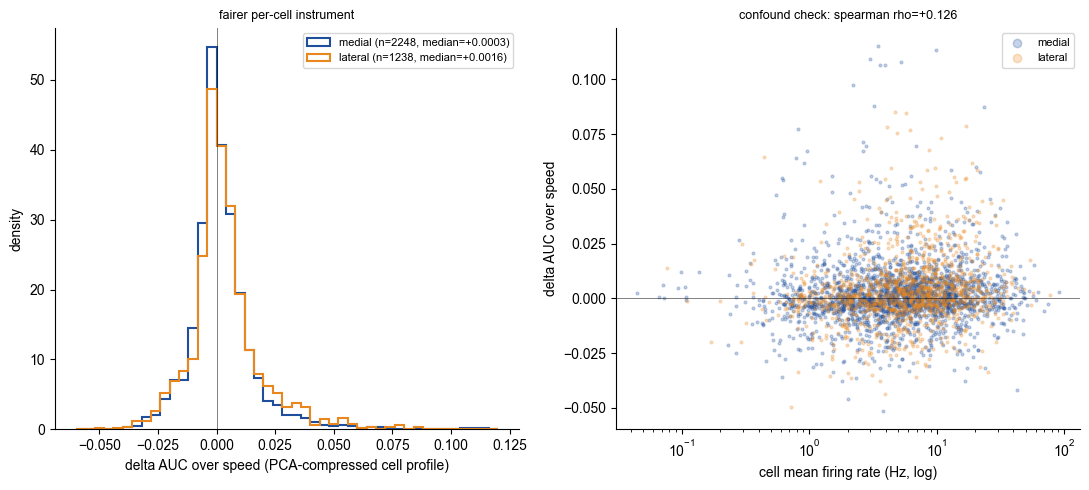

In [23]:
# --- firing-rate confound: do lateral cells simply fire more/cleaner? ---
print('mean firing rate (Hz) by side:')
print(pca_cell_df.groupby('side')['mean_rate'].describe()[['count','mean','50%']])
stat, p = mannwhitneyu(pca_cell_df[pca_cell_df.side=='medial']['mean_rate'],
                        pca_cell_df[pca_cell_df.side=='lateral']['mean_rate'])
print(f'pooled mann-whitney (medial vs lateral mean rate): p={p:.4g}')
rate_session = pca_cell_df.groupby(['mouse','day','side'])['mean_rate'].median().unstack('side')
stat2, p2 = wilcoxon(rate_session['medial'], rate_session['lateral'])
print(f'per-session wilcoxon (median rate): p={p2:.4f}, '
      f'medial higher in {int((rate_session["medial"]>rate_session["lateral"]).sum())}/{len(rate_session)}')
print()

from scipy.stats import spearmanr
rho, prho = spearmanr(pca_cell_df['mean_rate'], pca_cell_df['delta_pca'])
print(f'does delta depend on firing rate? spearman rho={rho:+.3f}, p={prho:.4g}')
print()

# rate-MATCHED comparison: within each session x firing-rate quartile, compare sides
pca_cell_df['rate_q'] = (pca_cell_df.groupby(['mouse','day'])['mean_rate']
                          .transform(lambda x: pd.qcut(x.rank(method='first'), 4, labels=False)))
strat = (pca_cell_df.groupby(['mouse','day','rate_q','side'])['delta_pca']
          .median().unstack('side').dropna())
stat3, p3 = wilcoxon(strat['medial'], strat['lateral'])
n_med3 = int((strat['medial'] > strat['lateral']).sum())
print(f'RATE-MATCHED (session x rate-quartile strata, n={len(strat)}): '
      f'wilcoxon p={p3:.4f}, medial higher in {n_med3}/{len(strat)} strata')
print(f'  median delta -- medial={strat["medial"].median():+.5f}, lateral={strat["lateral"].median():+.5f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
bins = np.linspace(-0.06, 0.12, 46)
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    v = pca_cell_df[pca_cell_df.side==side]['delta_pca']
    ax.hist(v, bins=bins, density=True, histtype='step', color=color, linewidth=1.5,
            label=f'{side} (n={len(v)}, median={v.median():+.4f})')
ax.axvline(0, color='k', linewidth=0.7, alpha=0.5)
ax.set_xlabel('delta AUC over speed (PCA-compressed cell profile)')
ax.set_ylabel('density'); ax.set_title('fairer per-cell instrument', fontsize=9)
ax.spines[['top','right']].set_visible(False); ax.legend(fontsize=8)

ax = axes[1]
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    sub = pca_cell_df[pca_cell_df.side==side]
    ax.scatter(sub['mean_rate'], sub['delta_pca'], s=4, alpha=0.25, color=color, label=side)
ax.set_xscale('log'); ax.axhline(0, color='k', linewidth=0.7, alpha=0.5)
ax.set_xlabel('cell mean firing rate (Hz, log)'); ax.set_ylabel('delta AUC over speed')
ax.set_title(f'confound check: spearman rho={rho:+.3f}', fontsize=9)
ax.spines[['top','right']].set_visible(False); ax.legend(fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_percell_pca_and_rate_confound.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Novel (`rz2`) vs. familiar (`rz1`) selectivity

`rz1` is the familiar context, `rz2` the novel one. Everything so far
measured selectivity by *magnitude only* (`|AUC-0.5|`), which can't tell
a cell that fires more for the novel context apart from one that fires
more for the familiar one. Here: use the *sign* of each cell's raw AUC
from Method 3 (`>0.5` = higher rate in `rz2`/novel, `<0.5` = higher rate
in `rz1`/familiar) to ask (a) is there an overall population-level skew
toward encoding novelty vs. familiarity, and (b) does that skew differ
between medial and lateral cells (e.g. one side specifically carrying
more of a "novelty" signal).

population-level novel/familiar bias (median signed AUC-0.5 per session, n=16 sessions): median=-0.0020, wilcoxon vs 0: stat=46.0, p=0.2744

contingency table (side x prefers_novel):
prefers_novel  False  True 
side                       
lateral          593    645
medial          1212   1036
chi-square test (side x novel-preferring): chi2=11.33, p=0.0007636
per-session wilcoxon (fraction novel-preferring, medial vs lateral): stat=11.0, p=0.0017, medial higher in 3/16 sessions


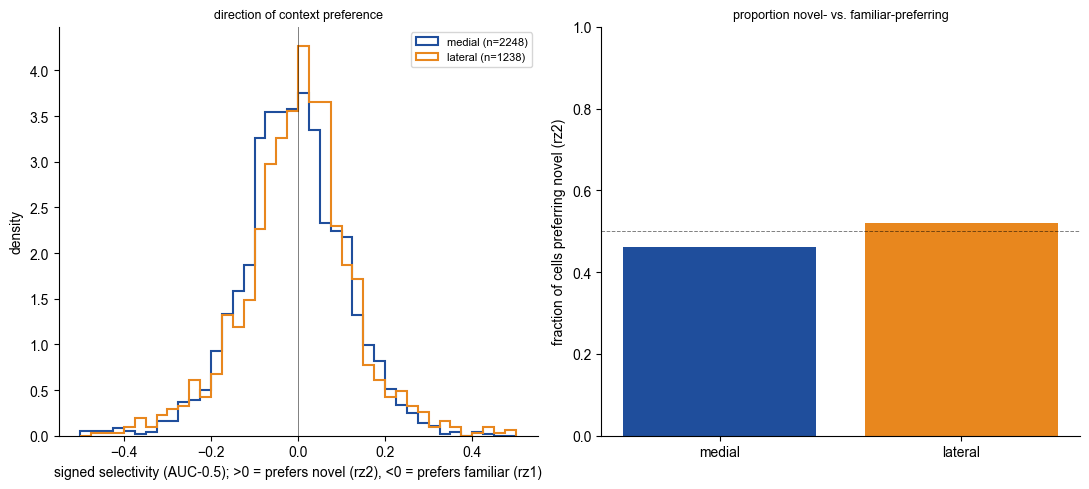

In [24]:
cell_df['prefers_novel'] = cell_df['auc'] > 0.5

# (a) population-level bias: per-session median signed selectivity, tested against 0
session_signed = cell_df.groupby(['mouse', 'day'])['auc'].apply(lambda x: (x - 0.5).median()).reset_index(name='median_signed_auc')
stat, p = wilcoxon(session_signed['median_signed_auc'])
print(f'population-level novel/familiar bias (median signed AUC-0.5 per session, n={len(session_signed)} sessions): '
      f'median={session_signed.median_signed_auc.median():+.4f}, wilcoxon vs 0: stat={stat}, p={p:.4f}')

# (b) medial vs lateral: does the PROPORTION of novel-preferring cells differ?
contingency = pd.crosstab(cell_df['side'], cell_df['prefers_novel'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print('\ncontingency table (side x prefers_novel):')
print(contingency)
print(f'chi-square test (side x novel-preferring): chi2={chi2:.2f}, p={p_chi2:.4g}')

session_prop = cell_df.groupby(['mouse', 'day', 'side'])['prefers_novel'].mean().unstack('side')
stat2, p2 = wilcoxon(session_prop['medial'], session_prop['lateral'])
n_med_higher = int((session_prop['medial'] > session_prop['lateral']).sum())
print(f'per-session wilcoxon (fraction novel-preferring, medial vs lateral): stat={stat2}, p={p2:.4f}, '
      f'medial higher in {n_med_higher}/{len(session_prop)} sessions')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
bins = np.linspace(-0.5, 0.5, 41)
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    vals = cell_df[cell_df.side == side]['auc'] - 0.5
    ax.hist(vals, bins=bins, density=True, histtype='step', color=color, linewidth=1.5, label=f'{side} (n={len(vals)})')
ax.axvline(0, color='k', linewidth=0.7, alpha=0.5)
ax.set_xlabel('signed selectivity (AUC-0.5); >0 = prefers novel (rz2), <0 = prefers familiar (rz1)')
ax.set_ylabel('density')
ax.set_title('direction of context preference', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

ax = axes[1]
props = cell_df.groupby('side')['prefers_novel'].mean()
ax.bar(['medial', 'lateral'], [props['medial'], props['lateral']], color=[MEDIAL_COLOR, LATERAL_COLOR])
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_ylabel('fraction of cells preferring novel (rz2)')
ax.set_ylim(0, 1)
ax.set_title('proportion novel- vs. familiar-preferring', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_novel_vs_familiar.pdf'), dpi=200, bbox_inches='tight')
plt.show()

## Digging into the novel/familiar direction effect

Three follow-up checks on the one medial/lateral effect that held up
(lateral MEC cells skew somewhat more novel-preferring than medial
cells, session-level p=0.0017): (1) is it consistent across all 4 mice
individually, or driven by one or two of them; (2) is it actually a
*layer* effect in disguise -- entorhinal layer composition differs a lot
between medial and lateral (`ENTm1`/`ENTm2` are almost purely medial,
`ENTm5` mostly lateral), so a layer-specific novelty bias could produce
exactly this pattern without there being any true *positional* (ML)
effect within a layer; (3) does it change with days of exposure to `rz2`
(it should fade if it's really about novelty, since `rz2` stops being
novel after day 1).

side    lateral    medial  n_medial  n_lateral
mouse                                         
M25    0.573034  0.466151       517        267
M26    0.606481  0.598007       602        216
M28    0.441281  0.291228       570        281
M29    0.500000  0.481216       559        474


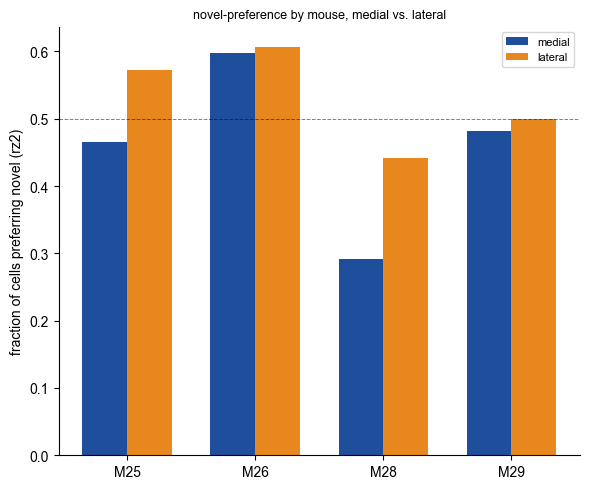

In [25]:
# (1) per-mouse breakdown
mouse_prop = cell_df.groupby(['mouse', 'side'])['prefers_novel'].mean().unstack('side')
mouse_prop['n_medial'] = cell_df[cell_df.side == 'medial'].groupby('mouse').size()
mouse_prop['n_lateral'] = cell_df[cell_df.side == 'lateral'].groupby('mouse').size()
print(mouse_prop)

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(mouse_prop))
width = 0.35
ax.bar(x - width / 2, mouse_prop['medial'], width, color=MEDIAL_COLOR, label='medial')
ax.bar(x + width / 2, mouse_prop['lateral'], width, color=LATERAL_COLOR, label='lateral')
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(mouse_prop.index)
ax.set_ylabel('fraction of cells preferring novel (rz2)')
ax.set_title('novel-preference by mouse, medial vs. lateral', fontsize=9)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_novel_familiar_by_mouse.pdf'), dpi=200, bbox_inches='tight')
plt.show()

In [26]:
# (2) is the medial/lateral skew actually a LAYER effect? -- check within
# ENTm3 specifically, the one layer that's roughly evenly split (55% medial,
# 45% lateral in the region table above), so a within-layer ML comparison is
# actually possible there (for ENTm1/ENTm2/ENTm5 one side has too few cells)
region_prop = cell_df.groupby('region')['prefers_novel'].agg(['mean', 'count'])
print('novel-preference by region, pooled across sides:')
print(region_prop.sort_values('mean'))
print()

region_side_prop = cell_df.groupby(['region', 'side'])['prefers_novel'].agg(['mean', 'count'])
print('novel-preference by region x side:')
print(region_side_prop)
print()

entm3 = cell_df[cell_df.region == 'ENTm3']
entm3_session_prop = entm3.groupby(['mouse', 'day', 'side'])['prefers_novel'].mean().unstack('side').dropna()
stat, p = wilcoxon(entm3_session_prop['medial'], entm3_session_prop['lateral'])
n_med_higher = int((entm3_session_prop['medial'] > entm3_session_prop['lateral']).sum())
print(f'WITHIN ENTm3 only (n={len(entm3_session_prop)} sessions with both sides represented): '
      f'medial mean={entm3["prefers_novel"][entm3.side=="medial"].mean():.3f}, '
      f'lateral mean={entm3["prefers_novel"][entm3.side=="lateral"].mean():.3f}, '
      f'per-session wilcoxon p={p:.4f}, medial higher in {n_med_higher}/{len(entm3_session_prop)}')

novel-preference by region, pooled across sides:
            mean  count
region                 
ENTm5   0.450500   1101
ENTm3   0.489022   1503
ENTm2   0.501603    624
ENTm1   0.531008    258

novel-preference by region x side:
                    mean  count
region side                    
ENTm1  medial   0.531008    258
ENTm2  lateral  0.571429      7
       medial   0.500810    617
ENTm3  lateral  0.568182    484
       medial   0.451423   1019
ENTm5  lateral  0.489960    747
       medial   0.367232    354

WITHIN ENTm3 only (n=9 sessions with both sides represented): medial mean=0.451, lateral mean=0.568, per-session wilcoxon p=0.1641, medial higher in 2/9


              mean             count       
side       lateral    medial lateral medial
day_rank                                   
1         0.530792  0.483412     341    422
2         0.464883  0.431925     299    639
3         0.602787  0.547307     287    687
4         0.437086  0.383065     151    248
5         0.537500  0.337302     160    252


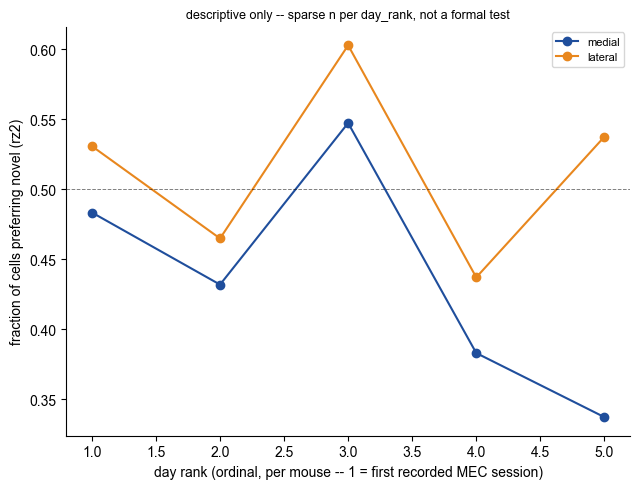


sessions per day_rank: {1: 4, 2: 4, 3: 4, 4: 2, 5: 2}


In [27]:
# (3) does the medial/lateral gap change with days of exposure to rz2?
cell_df['day_rank'] = cell_df.groupby('mouse')['day'].rank(method='dense').astype(int)
day_prop = cell_df.groupby(['day_rank', 'side'])['prefers_novel'].agg(['mean', 'count']).unstack('side')
print(day_prop)

fig, ax = plt.subplots(figsize=(6.5, 5))
day_means = cell_df.groupby(['day_rank', 'side'])['prefers_novel'].mean().unstack('side')
day_ns = cell_df.groupby(['day_rank', 'side']).size().unstack('side')
for side, color in [('medial', MEDIAL_COLOR), ('lateral', LATERAL_COLOR)]:
    ax.plot(day_means.index, day_means[side], color=color, marker='o', label=side)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('day rank (ordinal, per mouse -- 1 = first recorded MEC session)')
ax.set_ylabel('fraction of cells preferring novel (rz2)')
ax.set_title('descriptive only -- sparse n per day_rank, not a formal test', fontsize=9)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'mcvr_ml_decoding_novel_familiar_by_day.pdf'), dpi=200, bbox_inches='tight')
plt.show()
print('\nsessions per day_rank:', cell_df.groupby('day_rank')[['mouse','day']].apply(lambda g: g.drop_duplicates().shape[0]).to_dict())

## Summary

**Scope:** MEC only (`ENTm1/2/3/5/6`), 16/31 sessions, 4 mice (`M25`, `M26`,
`M28`, `M29`), 3486 cells. `M22` and `M27` drop out almost entirely -- their
probes recorded essentially no MEC.

### Headline: MEC population activity carries context information beyond speed

Using the position-binned firing rate **profile** across the trial (23 x 10cm
bins) rather than a trial-mean, and controlling with the animal's speed
profile binned identically:

| features | mean AUC |
|---|---|
| speed profile alone | 0.929 |
| population firing profiles alone | 0.972 |
| both together | 0.975 |

Adding neural profiles beats speed alone in **16/16 sessions**
(Wilcoxon p=3.1e-05, mean delta=+0.046). The gain is largest exactly where
speed does worst (M29 D28: 0.859 -> 0.988; M29 D27: 0.871 -> 0.992), and
vanishes only where speed already saturates at 0.97+ -- the opposite of what a
speed-driven artifact would look like. Context information in MEC is real and
not reducible to the animal's running pattern.

This matters because the behavioural confound is genuinely large: the *shape*
of the speed profile decodes context at AUC=0.901-0.929 on its own (`rz1` and
`rz2` decelerate at different track positions, 92 vs 122cm). A trial-mean speed
scalar decodes at only 0.552 -- so a scalar-level control would have badly
understated the problem.

### Per cell: very little beyond speed, on any instrument

| instrument | mean delta | median delta | frac > 0 |
|---|---|---|---|
| trial-mean (1 feature) | +0.0052 | +0.0027 | 60.7% |
| full profile (23 features) | +0.0022 | -0.0003 | 48.7% |
| profile PCA (4 features) | +0.0027 | +0.0007 | 52.8% |

The full-profile version is dimensionality-penalized (23 noisy features per
cell, ~120-340 trials); PCA-compressing to 4 components recovers part of that
(48.7% -> 52.8%) but still does not beat the 1-feature trial-mean. The honest
reading: individual cells add little on top of speed, while the *population*
adds a lot -- the context signal is distributed, not carried by identifiable
single cells.

### Medial vs. lateral: null everywhere once properly controlled

| test | result |
|---|---|
| population decoding, count-matched (raw) | p=0.82, medial higher 8/16 |
| population decoding, speed-residualized | p=0.28, medial higher 16/27* |
| ablation order curves (~60% remaining) | p=0.43, 8/16 |
| single-cell abs(AUC-0.5) selectivity | pooled p=0.75, per-session p=0.46 |
| XGBoost trial-mean delta | per-session p=0.53 |
| XGBoost profile delta | per-session p=0.018, lateral higher 14/16 |
| **XGBoost profile delta, PCA** | **per-session p=0.43, 7/16** |
| **profile delta, RATE-MATCHED** | **p=0.75, 30/64 strata** |

*from the earlier all-region run.

The one apparently-significant result (profile delta, p=0.018 favouring
lateral) **does not survive**. Lateral cells fire faster (median 6.12 vs
5.10 Hz, pooled p=2.2e-04) and the delta metric scales with firing rate
(Spearman rho=+0.126, p=7.3e-14) -- faster cells have less noisy profiles, so a
classifier gains more from them. Matching medial and lateral cells on firing
rate within each session (quartile strata) removes the effect entirely:
p=0.75, medial higher in 30/64 strata -- exactly chance. The PCA instrument
also shows it as null per-session (p=0.43) even before rate-matching.

Note the recurring pattern: several *pooled* cell-level tests reach
significance (delta_pca pooled p=0.0012, profile pooled p=1.3e-04) while the
matched per-session tests are null. Pooling thousands of non-independent cells
unevenly across 16 sessions manufactures significance. **The session-level
tests are the trustworthy ones throughout this notebook.**

### Outstanding caveat

The novel/familiar *direction* result (lateral cells more `rz2`-preferring,
per-session p=0.0017, 13/16 sessions) was computed on **raw trial-mean rates**
-- neither speed-controlled nor rate-matched. Given that firing rate differs
between the two sides and demonstrably drives metric behaviour here, that
result needs the same rate-matched treatment before it can be trusted. Its
day-invariance (the medial/lateral gap is present at every day rank and does
not fade as `rz2` becomes familiar) already argues it is not a novelty signal
in any case -- at most a stable `rz1`/`rz2` preference asymmetry.

### Bottom line

MEC population activity discriminates context well beyond what running
behaviour explains -- that part is solid and replicates in every session. But
there is **no evidence that mediolateral recording position predicts context
coding**, on any of seven tests, once firing rate and speed are properly
controlled.